# E69 · Truth without a gold standard: latent class models for noisy raters and diagnostic tests

| | |
|---|---|
| **Type** | Advanced worked example - read, run, modify |
| **Data** | Real: **seven pathologists** each classifying the same **118 cervical slides** for carcinoma (Holmquist et al. 1967, dichotomised as in Landis & Koch 1977 and Agresti 2002; `carcinoma` in the R package poLCA), and **Dawid & Skene's (1979) anaesthetists**: 5 doctors rating 45 patients' pre-operative health on a 4-point scale, one of them three times (`anesthesia` in the R package rater). Simulated data are used, clearly labelled, for a Hui-Walter identifiability experiment and a known-truth check |
| **You will learn** | Why **majority vote** is a model with strong, silent assumptions · the **two-class latent class model** (prevalence + per-rater sensitivity and specificity) with the class **marginalised by `logsumexp`** · **counting identifiability**: parameters vs degrees of freedom · **label switching** shown as a failure (r_hat, mirrored chains) and fixed by a "better than chance" (**Youden**) parameterisation · a **pairwise / score predictive check** that exposes **conditional dependence** · a **random-effects** latent class model that fits better yet **changes the meaning of the class** (Albert & Dodd's warning), and a **three-class** model that fits as well and stays interpretable · **Hui-Walter**: two tests, two populations, simulated with and without a prevalence difference · what **informative priors** buy when the data cannot answer · **Dawid-Skene** with K = 4 categories and **hierarchically pooled confusion matrices** vs unpooled vs EM · a **known-truth check** (simulated) of calibration and of majority vote · decisions: **which slides to send for expert adjudication** (value of information) and **which three pathologists to keep** |

## Who is right when nobody knows the answer?

Seven experienced pathologists look at the same 118 slides of cervical tissue and each says
"carcinoma" or "no carcinoma". On 34 slides all seven say no, on 16 all seven say yes, and on
the remaining 68 they disagree. There is **no gold standard**: no biopsy follow-up, no
consensus panel, nothing but the seven opinions.

The same situation is everywhere: several imperfect diagnostic tests for a disease with no
perfect test (tuberculosis, Lyme disease, many veterinary infections), crowdworkers labelling
images or sentences for machine learning, reviewers scoring grant proposals, radiologists
reading the same scans. The questions are always the same:

1. **What is the true label of each item**, and how sure can we be?
2. **How good is each rater** (sensitivity, specificity, a whole confusion matrix)?
3. **What is the prevalence** of each class?
4. **What should we do**: which items deserve an expensive expert opinion, and which raters are
   worth paying for?

The obvious answer, majority vote, answers only question 1, badly. The model-based answer
treats the true label as a **latent class** and the raters as noisy measurements of it
(Dawid & Skene 1979; Hui & Walter 1980). It can answer all four questions, but only under
assumptions that the data can partly check and partly cannot. This notebook is about both.

| part | data | question |
|---|---|---|
| 1-2 | carcinoma | what does majority vote assume? |
| 3 | carcinoma | the two-class latent class model; label switching |
| 4-5 | carcinoma | is conditional independence plausible? random effects and a third class |
| 6 | simulated + carcinoma | when can a model without a gold standard answer at all? |
| 7-8 | anaesthetists (+ simulated) | K = 4 categories: Dawid-Skene with pooled confusion matrices |
| 9 | carcinoma | decisions: adjudication and which raters to keep |

In [1]:
import logging
import time
import warnings
from itertools import combinations

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from scipy import special, stats

from pymc_challenges import data

RANDOM_SEED = 69
rng = np.random.default_rng(RANDOM_SEED)
az.style.use("arviz-variat")
logging.getLogger("pymc").setLevel(logging.WARNING)  # many small fits: no sampler banner each
warnings.filterwarnings("ignore", category=RuntimeWarning, module="arviz")
warnings.filterwarnings("ignore", message=".*effective sample size per chain.*")
BLUE, ORANGE, AQUA, GREY, PURPLE, RED = "#2a78d6", "#eb6834", "#1baf7a", "#8a8a86", "#8c5ac8", "#c8384e"
print(f"PyMC {pm.__version__}, ArviZ {az.__version__}, PyTensor {pytensor.__version__}")


def q(x, probs=(0.05, 0.5, 0.95), axis=None):
    """Posterior quantiles, rounded for printing."""
    return np.round(np.quantile(x, probs, axis=axis), 3)


def draws(idata, var):
    """Posterior draws of one variable as a NumPy array with (chain*draw) first."""
    da = idata.posterior[var]
    return da.stack(s=("chain", "draw")).transpose("s", ...).to_numpy()


def diag(idata, var_names):
    """Divergences, worst r_hat and smallest bulk ESS over the listed variables."""
    rh = max(float(az.rhat(idata.posterior[v]).max()) for v in var_names)
    es = min(float(az.ess(idata.posterior[v]).min()) for v in var_names)
    return (f"divergences {int(idata.sample_stats['diverging'].sum())}, max r_hat {rh:.3f}, "
            f"min bulk ESS {es:.0f}")

PyMC 6.3.2, ArviZ 1.3.0, PyTensor 3.3.2


---
# 1 · Seven pathologists, 118 slides

In [2]:
data.describe("carcinoma_pathologists")
carc = data.load("carcinoma_pathologists")
RATERS = list("ABCDEFG")
Y = (carc[RATERS].to_numpy() == 2).astype(int)          # 1 = "carcinoma"
N, J = Y.shape
k_pos = Y.sum(axis=1)                                    # positive calls per slide
patterns, pat_count = np.unique(Y, axis=0, return_counts=True)
print(f"{N} slides x {J} pathologists; {len(patterns)} distinct patterns of the {2**J} possible")
print("share of slides called positive by each pathologist:",
      dict(zip(RATERS, Y.mean(axis=0).round(2).tolist())))
print("slides by number of positive calls:", np.bincount(k_pos).tolist(), "(0, 1, ..., 7 calls)")

carcinoma_pathologists: Seven pathologists (A-G) each classified the same 118 slides of the uterine cervix for carcinoma (in situ or invasive). One row per slide: slide (1-118), A..G (1 = no carcinoma, 2 = carcinoma). There is no gold standard; 20 distinct rating patterns occur.
  source: Holmquist, McMahan & Williams (1967, Archives of Pathology), as dichotomised in Landis & Koch (1977, Biometrics 33:363-374) and Agresti (2002, Categorical Data Analysis, Table 13.1); distributed as `carcinoma` in the CRAN package poLCA (GPL >= 2; the URL). CONVERTED from the .rda with R (values unchanged, a slide index added) - keep the CSV in data/.
  url:    https://raw.githubusercontent.com/cran/poLCA/master/data/carcinoma.rda
118 slides x 7 pathologists; 20 distinct patterns of the 128 possible
share of slides called positive by each pathologist: {'A': 0.56, 'B': 0.67, 'C': 0.38, 'D': 0.27, 'E': 0.6, 'F': 0.21, 'G': 0.56}
slides by number of positive calls: [34, 10, 7, 8, 9, 16, 18, 16] (0, 1, ...

Pathologists differ a lot in how often they say "carcinoma": B calls 67% of the slides
positive, F only 21%. Either the slides B and F looked at differ (they did not - everyone saw
all 118) or they have different **thresholds**. Only 20 of the 128 possible patterns occur,
which already says the opinions are far from random.

Agreement between two raters is usually summarised by **Cohen's kappa**, the agreement beyond
what their marginal rates would produce by chance:
$\kappa = (p_o - p_e)/(1 - p_e)$.

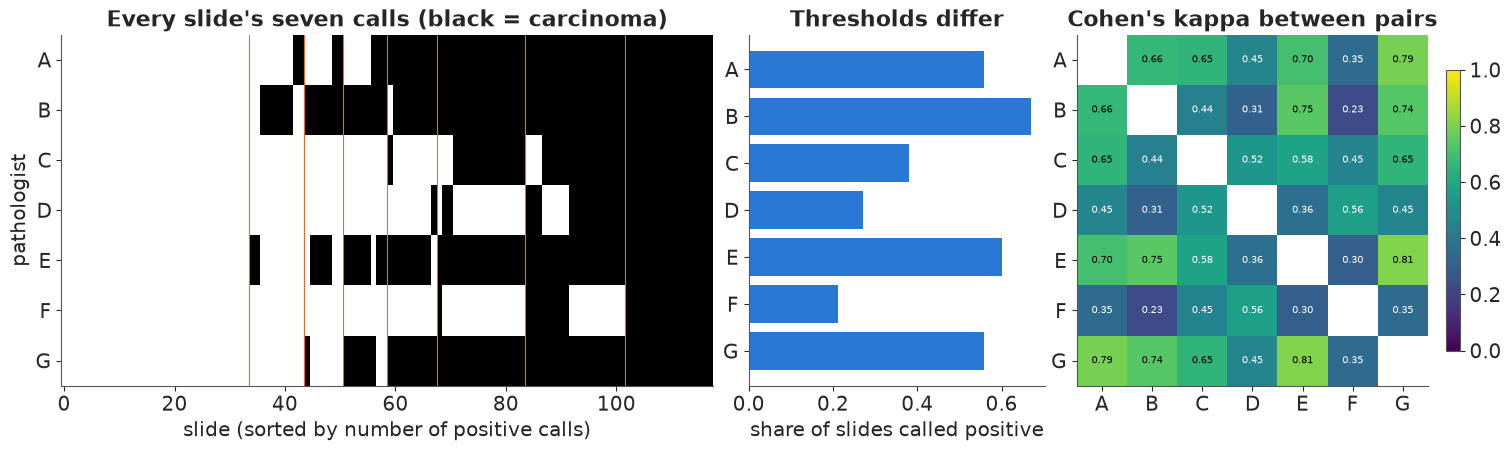

In [3]:
pairs = list(combinations(range(J), 2))


def kappa(a, b):
    po = np.mean(a == b)
    pe = a.mean() * b.mean() + (1 - a.mean()) * (1 - b.mean())
    return (po - pe) / (1 - pe)


K_mat = np.eye(J)
for a, b in pairs:
    K_mat[a, b] = K_mat[b, a] = kappa(Y[:, a], Y[:, b])

order = np.lexsort((Y @ 2 ** np.arange(J)[::-1], k_pos))   # by score, then pattern
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), width_ratios=[2.2, 1, 1.2])
axes[0].imshow(Y[order].T, aspect="auto", cmap="Greys", interpolation="nearest")
axes[0].set_yticks(range(J), RATERS)
axes[0].set(xlabel="slide (sorted by number of positive calls)", ylabel="pathologist",
            title="Every slide's seven calls (black = carcinoma)")
for x in np.cumsum(np.bincount(k_pos))[:-1]:
    axes[0].axvline(x - 0.5, color=ORANGE, lw=0.8)
axes[1].barh(range(J), Y.mean(axis=0), color=BLUE)
axes[1].set_yticks(range(J), RATERS)
axes[1].invert_yaxis()
axes[1].set(xlabel="share of slides called positive", title="Thresholds differ")
im = axes[2].imshow(np.where(np.eye(J, dtype=bool), np.nan, K_mat), cmap="viridis", vmin=0, vmax=1)
axes[2].set_xticks(range(J), RATERS)
axes[2].set_yticks(range(J), RATERS)
for a, b in pairs:
    for (r, c) in [(a, b), (b, a)]:
        axes[2].text(c, r, f"{K_mat[a, b]:.2f}", ha="center", va="center", fontsize=7,
                     color="w" if K_mat[a, b] < 0.6 else "k")
axes[2].set_title("Cohen's kappa between pairs")
fig.colorbar(im, ax=axes[2], shrink=0.8);

Kappa ranges from about 0.2 (B with F: one says yes to almost everything, the other to almost
nothing) to about 0.8. Kappa describes *agreement*; it does not say who is *right*. To talk about
accuracy we need a model of the truth.

---
# 2 · Majority vote, and what it assumes

With seven raters the majority is always defined. Majority vote calls a slide positive when
four or more pathologists do:

In [4]:
mv = (k_pos >= 4).astype(int)
agree_mv = (Y == mv[:, None])
mv_se = (Y[mv == 1] == 1).mean(axis=0)
mv_sp = (Y[mv == 0] == 0).mean(axis=0)
print(f"majority vote: {mv.sum()} of {N} slides positive ({mv.mean():.0%})")
print(pd.DataFrame({"agreement with MV": agree_mv.mean(axis=0), "'sensitivity' vs MV": mv_se,
                    "'specificity' vs MV": mv_sp}, index=RATERS).round(2).T)

majority vote: 59 of 118 slides positive (50%)
                        A     B     C     D     E     F     G
agreement with MV    0.94  0.81  0.88  0.77  0.88  0.71  0.94
'sensitivity' vs MV  1.00  0.98  0.76  0.54  0.98  0.42  1.00
'specificity' vs MV  0.88  0.64  1.00  1.00  0.78  1.00  0.88


Majority vote is itself a model, with three silent assumptions:

* **every rater is equally good** (B, who says yes to two thirds of slides, gets the same vote
  as F, who says yes to one fifth);
* **errors are symmetric** (a false positive is as likely as a false negative);
* the label is **certain**: a 4-3 slide is as positive as a 7-0 slide.

The "sensitivity against the majority" table is also circular: each rater is part of the
majority it is scored against, and the majority's own mistakes are counted as the rater's.
Section 8 measures, on simulated data where the truth is known, how much accuracy majority
vote leaves on the table.

---
# 3 · The two-class latent class model

## 3.1 · The model

Let $D_i \in \{0, 1\}$ be the unobserved true status of slide $i$, with prevalence
$\pi = P(D_i = 1)$. Rater $j$ has **sensitivity** $\mathrm{Se}_j = P(y_{ij} = 1 \mid D_i = 1)$
and **specificity** $\mathrm{Sp}_j = P(y_{ij} = 0 \mid D_i = 0)$. The key assumption is
**conditional independence**: given the true status, the raters err independently. Then

$$p(y_i) = \pi \prod_j \mathrm{Se}_j^{y_{ij}} (1 - \mathrm{Se}_j)^{1 - y_{ij}}
         + (1 - \pi) \prod_j (1 - \mathrm{Sp}_j)^{y_{ij}} \mathrm{Sp}_j^{1 - y_{ij}} .$$

The discrete $D_i$ never enters the sampler: we sum it out on the log scale with
`pt.logaddexp` (a two-term `logsumexp`). Afterwards the posterior probability that slide $i$
is positive is the share of that sum contributed by the first term,
$P(D_i = 1 \mid y_i) = \pi\, p(y_i \mid D = 1) / p(y_i)$, averaged over the posterior.

**Can the data identify it?** With $J$ binary raters the data are a multinomial over $2^J$
patterns: $2^J - 1$ free cell probabilities ("degrees of freedom"). The model has $2J + 1$
parameters. Necessary for identification: $2^J - 1 \ge 2J + 1$, i.e. **at least three raters**
(7 = 7 with three raters, just identified; here $127 \gg 15$). Section 6 returns to this.

## 3.2 · A first attempt, and label switching

The model has an exact symmetry. Rename "diseased" as "healthy" and replace
$(\pi, \mathrm{Se}_j, \mathrm{Sp}_j)$ by $(1 - \pi, 1 - \mathrm{Sp}_j, 1 - \mathrm{Se}_j)$: the
likelihood is unchanged. With symmetric priors (Beta(1, 1) on everything) the posterior has two
mirror-image modes, in one of which the pathologists are *worse than a coin flip*. We start
four chains at two different points, as one should when checking convergence.

In [5]:
def lcm2(Y_, youden=True, se_prior=None, sp_prior=None):
    """Two-class latent class model with conditional independence.

    youden=True parameterises Se_j = fpr_j + (1 - fpr_j) * u_j, so Se_j > 1 - Sp_j (every rater
    better than chance). youden=False puts Beta priors on Se_j and Sp_j directly; se_prior /
    sp_prior map a rater index to the (a, b) of an informative Beta (default Beta(1, 1)).
    """
    R = Y_.shape[1]
    se_ab = np.array([(se_prior or {}).get(j, (1.0, 1.0)) for j in range(R)])
    sp_ab = np.array([(sp_prior or {}).get(j, (1.0, 1.0)) for j in range(R)])
    with pm.Model(coords={"rater": np.arange(R), "item": np.arange(len(Y_))}) as m:
        pi = pm.Beta("pi", 1.0, 1.0)
        fpr = pm.Beta("fpr", sp_ab[:, 1], sp_ab[:, 0], dims="rater")   # fpr = 1 - Sp
        if youden:
            u = pm.Beta("u", 1.0, 1.0, dims="rater")
            se = pm.Deterministic("se", fpr + (1 - fpr) * u, dims="rater")
        else:
            se = pm.Beta("se", se_ab[:, 0], se_ab[:, 1], dims="rater")
        pm.Deterministic("sp", 1 - fpr, dims="rater")
        l1 = pt.log(pi) + (Y_ * pt.log(se) + (1 - Y_) * pt.log1p(-se)).sum(axis=1)
        l0 = pt.log1p(-pi) + (Y_ * pt.log(fpr) + (1 - Y_) * pt.log1p(-fpr)).sum(axis=1)
        ll = pt.logaddexp(l1, l0)                     # D summed out
        pm.Potential("lik", ll.sum())
        pm.Deterministic("ll", ll, dims="item")
        pm.Deterministic("p_pos", pt.exp(l1 - ll), dims="item")
    return m


mirror = [{"pi": 0.4, "se": np.full(J, 0.8), "fpr": np.full(J, 0.2)},
          {"pi": 0.6, "se": np.full(J, 0.2), "fpr": np.full(J, 0.8)}] * 2
t0 = time.time()
with lcm2(Y, youden=False):
    # a per-chain list of initvals runs PyMC's own NUTS (multiprocess: cores=2)
    idata_sw = pm.sample(nuts_sampler="pymc", initvals=mirror, chains=4, cores=2,
                         random_seed=RANDOM_SEED, progressbar=False)
print(f"{time.time() - t0:.0f} s; {diag(idata_sw, ['pi', 'se', 'sp'])}")
print("per-chain posterior means:")
print(pd.DataFrame({"pi": idata_sw.posterior["pi"].mean("draw"),
                    "Se[A]": idata_sw.posterior["se"].sel(rater=0).mean("draw"),
                    "Sp[A]": idata_sw.posterior["sp"].sel(rater=0).mean("draw"),
                    "Se[F]": idata_sw.posterior["se"].sel(rater=5).mean("draw")}).round(2))

The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


2 s; divergences 0, max r_hat 1.738, min bulk ESS 6
per-chain posterior means:
     pi  Se[A]  Sp[A]  Se[F]
0  0.53   0.95   0.88   0.41
1  0.47   0.12   0.05   0.02
2  0.53   0.95   0.88   0.40
3  0.47   0.12   0.06   0.02


Chains 0 and 2 found pathologist A with sensitivity about 0.95; chains 1 and 3 found 0.12, the
mirror image (and F's sensitivity 0.40 vs 0.02). Each chain is a healthy sample *of its own mode*
(no divergences), and the two modes describe the data equally well. The pooled r_hat is 1.7 with
a bulk ESS of 6. The prevalence barely shows it (0.53 vs 0.47), because $\pi$ happens to sit
near 1/2 - a warning against checking convergence on one convenient parameter.

Starting all chains near the centre of the prior, as nutpie does by default, can easily put all
four in the same mode. The posterior would still be bimodal; one would just not see it.

## 3.3 · The fix: raters better than chance

The mirror mode is not a different scientific hypothesis, it is a relabelling. We remove it with
a constraint that is true by assumption for any rater worth modelling: a rater says "yes" more
often to diseased slides than to healthy ones, $\mathrm{Se}_j > 1 - \mathrm{Sp}_j$ (positive
**Youden index** $\mathrm{Se} + \mathrm{Sp} - 1$). The parameterisation

$$\mathrm{fpr}_j = 1 - \mathrm{Sp}_j \sim \mathrm{Beta}(1, 1), \qquad
  \mathrm{Se}_j = \mathrm{fpr}_j + (1 - \mathrm{fpr}_j)\, u_j, \quad u_j \sim \mathrm{Beta}(1, 1)$$

builds the constraint in, and removes the mirror mode entirely. What does it imply before seeing
data? Simulate the prior predictive number of positive calls per slide:

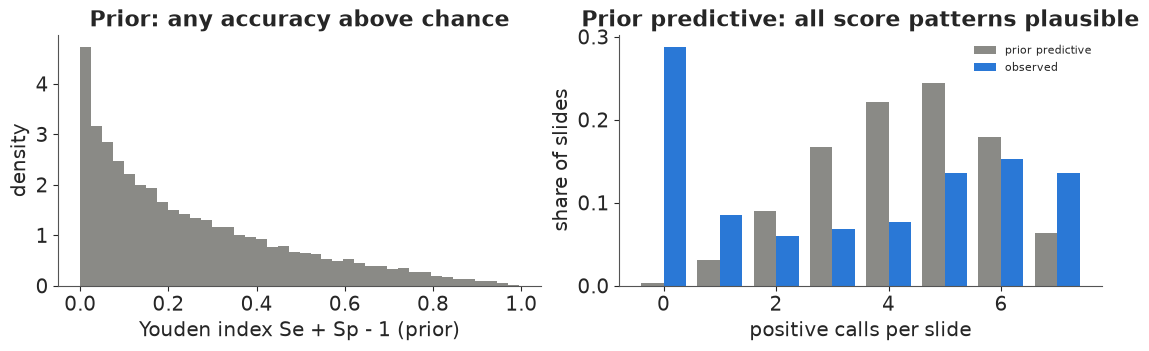

In [6]:
S = 4000
pr = np.random.default_rng(1)
pi_p = pr.beta(1, 1, S)
fpr_p = pr.beta(1, 1, (S, J))
se_p = fpr_p + (1 - fpr_p) * pr.beta(1, 1, (S, J))
D_p = pr.random(S) < pi_p
kp_prior = (pr.random((S, J)) < np.where(D_p[:, None], se_p, fpr_p)).sum(axis=1)
youden_p = se_p + (1 - fpr_p) - 1
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(youden_p.ravel(), bins=40, color=GREY, density=True)
axes[0].set(xlabel="Youden index Se + Sp - 1 (prior)", ylabel="density",
            title="Prior: any accuracy above chance")
axes[1].bar(np.arange(J + 1) - 0.2, np.bincount(kp_prior, minlength=J + 1) / S, 0.4, color=GREY,
            label="prior predictive")
axes[1].bar(np.arange(J + 1) + 0.2, np.bincount(k_pos, minlength=J + 1) / N, 0.4, color=BLUE,
            label="observed")
axes[1].set(xlabel="positive calls per slide", ylabel="share of slides",
            title="Prior predictive: all score patterns plausible")
axes[1].legend(fontsize=8);

The prior allows anything from useless to perfect raters, but the Youden index leans toward
small values, and the prior predictive shows what that means: raters this mediocre would almost
**never be unanimous** (under 1% of slides with 0 calls, 6% with 7), while 42% of the real slides
are unanimous. "Uniform on accuracy" is not "uninformative about agreement". We keep it anyway,
for two reasons: with 118 slides spread over 127 pattern cells the data overwhelm it, and it lets
us compare with maximum likelihood below. With fewer items, a prior that expects competent raters
(say fpr ~ Beta(1, 4) and u ~ Beta(3, 1)) would be the better choice. Now fit, nutpie defaults.

In [7]:
t0 = time.time()
with lcm2(Y) as m_ci:
    idata_ci = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"{time.time() - t0:.0f} s, tuning steps {idata_ci.posterior.attrs.get('tuning_steps')}; "
      f"{diag(idata_ci, ['pi', 'se', 'sp'])}")


def rater_table(idata, cols=("se", "sp")):
    out = {}
    for c in cols:
        x = draws(idata, c)
        out[c] = [f"{np.mean(x[:, j]):.2f} [{np.quantile(x[:, j], 0.05):.2f}, "
                  f"{np.quantile(x[:, j], 0.95):.2f}]" for j in range(x.shape[1])]
    return pd.DataFrame(out, index=RATERS)


print(f"prevalence pi: mean {draws(idata_ci, 'pi').mean():.3f}, 90% {q(draws(idata_ci, 'pi'))[[0, 2]]}")
rater_table(idata_ci)

2 s, tuning steps 400; divergences 0, max r_hat 1.003, min bulk ESS 1742
prevalence pi: mean 0.526, 90% [0.442 0.609]


,se,sp
A,"0.95 [0.88, 1.00]","0.87 [0.79, 0.94]"
B,"0.97 [0.93, 0.99]","0.67 [0.55, 0.78]"
C,"0.72 [0.61, 0.82]","0.98 [0.95, 1.00]"
D,"0.52 [0.41, 0.63]","0.98 [0.95, 1.00]"
E,"0.96 [0.91, 0.99]","0.80 [0.70, 0.89]"
F,"0.41 [0.31, 0.51]","0.98 [0.95, 1.00]"
G,"0.98 [0.93, 1.00]","0.91 [0.82, 0.98]"


**Check against maximum likelihood.** Agresti (2002) and the poLCA documentation report a
maximised log-likelihood of $-317.2568$ for this model. A few lines of EM (the algorithm
Dawid & Skene introduced for exactly this problem) reproduce it:

In [8]:
def em_lcm2(Y_, iters=3000):
    pi_, se_, fp_ = 0.5, np.full(Y_.shape[1], 0.8), np.full(Y_.shape[1], 0.2)
    for _ in range(iters):
        l1 = np.log(pi_) + (Y_ * np.log(se_) + (1 - Y_) * np.log1p(-se_)).sum(axis=1)
        l0 = np.log1p(-pi_) + (Y_ * np.log(fp_) + (1 - Y_) * np.log1p(-fp_)).sum(axis=1)
        ll = np.logaddexp(l1, l0)
        w = np.exp(l1 - ll)                                       # E-step: P(D = 1 | y)
        pi_ = w.mean()                                            # M-step
        se_ = np.clip((w[:, None] * Y_).sum(axis=0) / w.sum(), 1e-12, 1 - 1e-12)
        fp_ = np.clip(((1 - w)[:, None] * Y_).sum(axis=0) / (1 - w).sum(), 1e-12, 1 - 1e-12)
    return pi_, se_, 1 - fp_, ll.sum()


pi_em, se_em, sp_em, ll_em = em_lcm2(Y)
print(f"EM log-likelihood {ll_em:.4f}, prevalence {pi_em:.3f}")
print(pd.DataFrame({"Se (EM)": se_em, "Sp (EM)": sp_em,
                    "Se (posterior mean)": draws(idata_ci, "se").mean(axis=0),
                    "Sp (posterior mean)": draws(idata_ci, "sp").mean(axis=0)}, index=RATERS).round(3).T)

EM log-likelihood -317.2568, prevalence 0.501
                         A      B      C      D      E      F      G
Se (EM)              1.000  0.983  0.761  0.541  0.979  0.423  1.000
Sp (EM)              0.883  0.646  1.000  1.000  0.777  1.000  0.883
Se (posterior mean)  0.950  0.969  0.719  0.517  0.961  0.406  0.977
Sp (posterior mean)  0.874  0.670  0.982  0.982  0.799  0.983  0.907


The log-likelihood matches to four decimals. The maximum likelihood estimates put three
sensitivities (A, G, nearly B) and three specificities (C, D, F) **exactly on the boundary**:
"pathologist A never misses a carcinoma" from 118 slides. The posterior means are pulled
inside (0.95 instead of 1.00), with intervals that say how far the data allow: a 90% lower bound
of about 0.88 for A's sensitivity. That is the practical value of the Bayesian fit here: honest
uncertainty where maximum likelihood gives a corner.

The model's picture is clear and plausible: two styles of pathologist. A, B, E, G rarely miss
(sensitivity 0.95 or more) but over-call (specificity 0.67-0.91); C, D, F almost never over-call
but miss 28-59% of carcinomas. Prevalence about 0.53.

---
# 4 · Is conditional independence believable?

Conditional independence says that, once the true status is known, one pathologist's call tells
you nothing about another's. For slides that are genuinely borderline this is implausible:
a hard slide is hard for everyone. The model is fitted to the whole pattern table, but two
summaries are sensitive to exactly this failure:

* the distribution of the **number of positive calls** per slide (0-7); dependence among raters
  within a class piles slides into the middle scores the model cannot produce;
* the **pairwise agreement** of every pair of raters (21 pairs).

We replicate the 118 slides from the posterior (new true statuses, new calls) and compare.

In [9]:
def replicate_lc(pi_or_w, rates, n_rep=1000, seed=0):
    """Generic latent class simulator: class weights (S, C) and positive rates (S, J, C)."""
    g = np.random.default_rng(seed)
    idx = g.choice(len(rates), n_rep, replace=False)
    w, r = pi_or_w[idx], rates[idx]
    cls = (g.random((n_rep, N, 1)) > np.cumsum(w, axis=1)[:, None, :]).sum(axis=2)  # (rep, N)
    p = np.take_along_axis(r[:, None, :, :], cls[:, :, None, None], axis=3)[..., 0]  # (rep, N, J)
    return (g.random(p.shape) < p).astype(int)


def score_hist(Yr):
    return np.stack([(Yr.sum(axis=-1) == k).sum(axis=-1) for k in range(J + 1)], axis=-1)


def pair_agree(Yr):
    return np.stack([(Yr[..., a] == Yr[..., b]).mean(axis=-1) for a, b in pairs], axis=-1)


pi_d = draws(idata_ci, "pi")
w_ci = np.stack([1 - pi_d, pi_d], axis=1)
rates_ci = np.stack([1 - draws(idata_ci, "sp"), draws(idata_ci, "se")], axis=2)
yrep_ci = replicate_lc(w_ci, rates_ci)
obs_score, obs_agree = score_hist(Y), pair_agree(Y)


def ppc_summary(yrep, label):
    sh, ag = score_hist(yrep), pair_agree(yrep)
    z = (obs_agree - ag.mean(axis=0)) / ag.std(axis=0)
    p_hi = (sh >= obs_score).mean(axis=0)
    print(f"{label}: observed vs replicated (mean) slides by score")
    print(pd.DataFrame({"observed": obs_score, "replicated": sh.mean(axis=0).round(1),
                        "P(rep >= obs)": p_hi.round(3)}, index=range(J + 1)).T)
    print(f"  pairwise agreement z-scores: min {z.min():.2f}, max {z.max():.2f}; "
          f"pairs with |z| > 2: {int((np.abs(z) > 2).sum())} of {len(pairs)}")
    return sh, z


sh_ci, z_ci = ppc_summary(yrep_ci, "conditional independence")

conditional independence: observed vs replicated (mean) slides by score
                    0       1      2      3      4     5       6       7
observed       34.000  10.000  7.000  8.000  9.000  16.0  18.000  16.000
replicated     22.500  23.100  8.500  2.200  7.500  22.3  23.800   8.100
P(rep >= obs)   0.043   0.995  0.682  0.012  0.378   0.9   0.902   0.025
  pairwise agreement z-scores: min 0.17, max 2.51; pairs with |z| > 2: 2 of 21


The failure is in the middle of the score distribution. The model expects about 23 slides with
exactly one positive call and 2 with exactly three; the data have 10 and 8 (posterior predictive
probabilities 0.995 and 0.012). It also expects too few unanimous slides at both ends (22 vs 34
with no positive call, 8 vs 16 with seven). The pairwise agreements lean the same way: *every*
pair agrees more often than the model predicts (z from 0.2 to 2.5), which is what errors shared
between raters look like. The pattern is the signature of
**conditional dependence**: slides that fool one pathologist tend to fool several, so
"3 of 7" is more common than independent errors allow, and "1 of 7" (one idiosyncratic error)
less.

Why this matters: under conditional independence the model reads agreement between raters as
evidence that they are all *accurate*. If part of that agreement is shared confusion, accuracy
(and our certainty about the true labels) is overstated.

---
# 5 · Two ways to model the dependence

## 5.1 · Random effects: a latent "difficulty" per slide

Qu, Tan & Kutner (1996) gave each item a continuous random effect $b_i \sim \mathcal N(0, 1)$
that shifts every rater's probability of a positive call within a class:

$$P(y_{ij} = 1 \mid D_i = d, b_i) = \operatorname{logit}^{-1}(a_{jd} + s\, b_i).$$

(They used a probit link and allowed a different $s$ per class; we use a logit and one shared
$s$.) Now there are two latent quantities per slide. The discrete $D_i$ is summed out as before;
the continuous $b_i$ is integrated out by **Gauss-Hermite quadrature** with 20 nodes, all
inside one `logsumexp`. Sensitivity and specificity become *averages over slides*:
$\mathrm{Se}_j = \int \operatorname{logit}^{-1}(a_{j1} + s b)\,\phi(b)\,db$. The "better than
chance" constraint is $a_{j1} = a_{j0} + \delta_j$ with $\delta_j > 0$.

In [10]:
GH_X, GH_W = np.polynomial.hermite_e.hermegauss(20)       # nodes/weights for exp(-x^2/2)
GH_W = GH_W / np.sqrt(2 * np.pi)                           # now a quadrature for N(0, 1)
print(f"Gauss-Hermite check: E[b^2] = {GH_W @ GH_X**2:.6f}, E[logistic(1 + 2b)] = "
      f"{GH_W @ special.expit(1 + 2 * GH_X):.5f} vs Monte Carlo "
      f"{special.expit(1 + 2 * np.random.default_rng(0).standard_normal(10**6)).mean():.5f}")


def log_bern_sum(eta):
    """eta (nodes, J) -> (N, nodes): sum_j log P(y_ij | eta)."""
    lp = (Y[:, None, :] * (-pt.softplus(-eta))[None] + (1 - Y[:, None, :]) * (-pt.softplus(eta))[None])
    return lp.sum(axis=-1)


with pm.Model(coords={"rater": RATERS, "item": np.arange(N)}) as m_re:
    pi = pm.Beta("pi", 1.0, 1.0)
    a0 = pm.Normal("a0", -2.0, 1.5, dims="rater")
    delta = pm.HalfNormal("delta", 4.0, dims="rater")
    a1 = pm.Deterministic("a1", a0 + delta, dims="rater")
    s = pm.HalfNormal("s", 1.5)
    eta0 = a0[None, :] + s * GH_X[:, None]                  # (nodes, rater)
    eta1 = a1[None, :] + s * GH_X[:, None]
    l1 = pt.log(pi) + pt.logsumexp(np.log(GH_W)[None] + log_bern_sum(eta1), axis=1)
    l0 = pt.log1p(-pi) + pt.logsumexp(np.log(GH_W)[None] + log_bern_sum(eta0), axis=1)
    ll = pt.logaddexp(l1, l0)
    pm.Potential("lik", ll.sum())
    pm.Deterministic("ll", ll, dims="item")
    pm.Deterministic("p_pos", pt.exp(l1 - ll), dims="item")
    pm.Deterministic("se", GH_W @ pt.sigmoid(eta1), dims="rater")
    pm.Deterministic("sp", 1 - GH_W @ pt.sigmoid(eta0), dims="rater")

t0 = time.time()
with m_re:
    idata_re = pm.sample(random_seed=RANDOM_SEED, progressbar=False)
print(f"{time.time() - t0:.0f} s; {diag(idata_re, ['pi', 'a0', 'delta', 's'])}")
print(f"s (random-effect sd, logit scale): {q(draws(idata_re, 's'))}; "
      f"prevalence: {q(draws(idata_re, 'pi'))}")
rater_table(idata_re)

Gauss-Hermite check: E[b^2] = 1.000000, E[logistic(1 + 2b)] = 0.64773 vs Monte Carlo 0.64797


4 s; divergences 0, max r_hat 1.004, min bulk ESS 794
s (random-effect sd, logit scale): [3.392 4.26  5.143]; prevalence: [0.223 0.516 0.878]


,se,sp
A,"0.70 [0.56, 0.90]","0.58 [0.47, 0.71]"
B,"0.84 [0.71, 0.97]","0.50 [0.38, 0.65]"
C,"0.52 [0.37, 0.73]","0.78 [0.67, 0.87]"
D,"0.32 [0.23, 0.44]","0.78 [0.71, 0.87]"
E,"0.79 [0.63, 0.95]","0.59 [0.46, 0.73]"
F,"0.25 [0.18, 0.36]","0.82 [0.76, 0.89]"
G,"0.73 [0.58, 0.90]","0.62 [0.51, 0.74]"


In [11]:
g = np.random.default_rng(1)
idx = g.choice(len(draws(idata_re, "pi")), 1000, replace=False)
pi_r, a0_r, a1_r, s_r = (draws(idata_re, v)[idx] for v in ["pi", "a0", "a1", "s"])
D_r = g.random((1000, N)) < pi_r[:, None]
b_r = g.standard_normal((1000, N))
eta_r = np.where(D_r[..., None], a1_r[:, None, :], a0_r[:, None, :]) + (s_r[:, None] * b_r)[..., None]
yrep_re = (g.random(eta_r.shape) < special.expit(eta_r)).astype(int)
sh_re, z_re = ppc_summary(yrep_re, "random effects")

random effects: observed vs replicated (mean) slides by score
                    0       1       2      3       4       5       6       7
observed       34.000  10.000   7.000   8.00   9.000  16.000  18.000  16.000
replicated     28.100  12.100  10.100  10.90  13.200  14.200  11.800  17.600
P(rep >= obs)   0.181   0.758   0.874   0.85   0.896   0.351   0.064   0.627
  pairwise agreement z-scores: min -0.50, max 1.91; pairs with |z| > 2: 0 of 21


The random-effects model reproduces the score distribution (every posterior predictive
probability between 0.06 and 0.9) and the pairwise agreements (no |z| > 2). By this check it is
a much better model. But look at what it says about the pathologists and the slides:

* the random-effect sd is about 4 on the logit scale - **larger than the gaps between the
  classes** for most pathologists;
* the prevalence is anywhere from about 0.2 to 0.9;
* sensitivities have collapsed to 0.25-0.84 and specificities to 0.50-0.82.

The continuous slide effect has taken over the job of the class. The picture is clearest in the
probability each model gives that a slide has carcinoma, as a function of how many pathologists
said so:

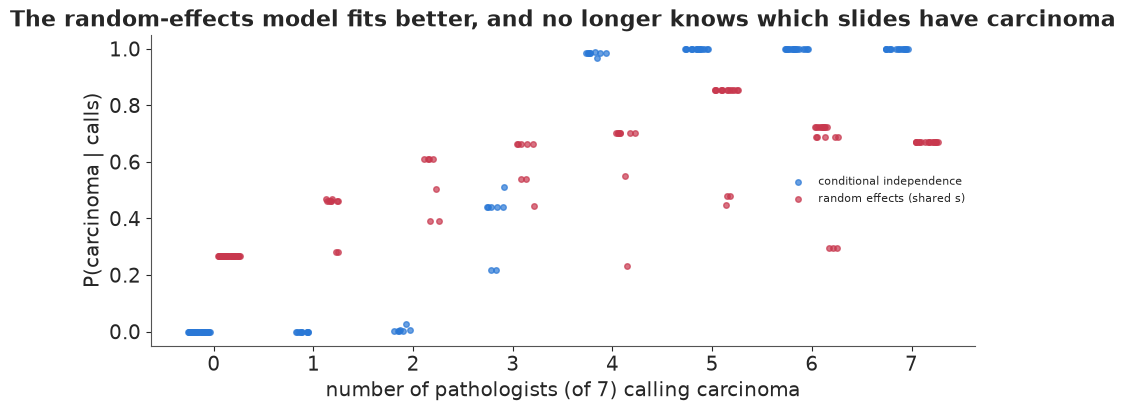

In [12]:
def p_by_score(idata):
    p = idata.posterior["p_pos"].mean(("chain", "draw")).to_numpy()
    return p


fig, ax = plt.subplots(figsize=(9, 4))
jit = np.random.default_rng(2).uniform(-0.12, 0.12, N)
ax.scatter(k_pos + jit - 0.15, p_by_score(idata_ci), s=16, color=BLUE, alpha=0.7,
           label="conditional independence")
ax.scatter(k_pos + jit + 0.15, p_by_score(idata_re), s=16, color=RED, alpha=0.7,
           label="random effects (shared s)")
ax.set(xlabel="number of pathologists (of 7) calling carcinoma", ylabel="P(carcinoma | calls)",
       title="The random-effects model fits better, and no longer knows which slides have carcinoma")
ax.legend(fontsize=8, loc="center right");

Under conditional independence the probability of carcinoma climbs from 0 to 1 as more
pathologists say yes, crossing 1/2 at three or four calls. Under the random-effects model a slide
on which **all seven** pathologists see nothing has about a 27% chance of carcinoma, and a
slide on which all seven see carcinoma only about 67%, less than some slides with five calls. The
model is not wrong about the data; it has found a different explanation for them: slides vary
along a continuous "looks malignant" scale, and the two classes are no longer tied to the pathologists' calls in any strong way.

This is **Albert & Dodd's (2004) warning**: different conditional-dependence structures can fit
the observed patterns equally well and still give very different sensitivities, specificities
and prevalence, because with no gold standard the class is defined only through the model.
A better fit is not a better answer if the latent class stopped meaning "carcinoma".

## 5.2 · A third class: slides that are genuinely ambiguous

Agresti (2002, p. 543) fits a **three-class** model to these data (maximised log-likelihood
-293.7 against -317.3 for two classes, as reproduced in the poLCA documentation). The
interpretation is direct: there are clearly negative slides, clearly positive slides, and a
group of **borderline** slides on which each pathologist's call depends on his or her threshold.
We check it with the same predictive tools. Conditional
independence is then assumed *within* each of the three classes.

The label-switching fix generalises: for each pathologist the probability of a positive call
must increase from class "negative" to "ambiguous" to "positive". We sample the logits
$a_{j,\cdot}$ with the `ordered` transform along the class axis.

In [13]:
CLS = ["negative", "ambiguous", "positive"]
with pm.Model(coords={"rater": RATERS, "item": np.arange(N), "cls": CLS}) as m_lc3:
    w = pm.Dirichlet("w", np.ones(3), dims="cls")
    a = pm.Normal("a", np.array([-2.5, 0.0, 2.5]), 2.0, dims=("rater", "cls"),
                  transform=pm.distributions.transforms.ordered)
    lp = (Y[:, :, None] * (-pt.softplus(-a))[None]
          + (1 - Y[:, :, None]) * (-pt.softplus(a))[None]).sum(axis=1)       # (item, cls)
    lj = pt.log(w)[None] + lp
    ll = pt.logsumexp(lj, axis=1)
    pm.Potential("lik", ll.sum())
    pm.Deterministic("ll", ll, dims="item")
    pm.Deterministic("p_cls", pt.exp(lj - ll[:, None]), dims=("item", "cls"))
    pm.Deterministic("p_pos", pt.exp(lj[:, 2] - ll), dims="item")
    pm.Deterministic("rate", pt.sigmoid(a), dims=("rater", "cls"))

t0 = time.time()
with m_lc3:
    idata_lc3 = pm.sample(random_seed=RANDOM_SEED, progressbar=False,
                          initvals={"a": np.tile([-2.0, 0.0, 2.0], (J, 1))})
print(f"{time.time() - t0:.0f} s; {diag(idata_lc3, ['w', 'a'])}")
print("class weights:", {c: q(draws(idata_lc3, "w")[:, k]).tolist() for k, c in enumerate(CLS)})
# az.summary on a 2-D variable can mislabel rows: tabulate from the arrays directly
rate_d = draws(idata_lc3, "rate")                                            # (S, rater, cls)
print("P(positive call | class), posterior mean:")
print(pd.DataFrame(rate_d.mean(axis=0), index=RATERS, columns=CLS).round(2).T)

3 s; divergences 0, max r_hat 1.006, min bulk ESS 1758
class weights: {'negative': [0.291, 0.372, 0.456], 'ambiguous': [0.12, 0.191, 0.274], 'positive': [0.346, 0.435, 0.521]}
P(positive call | class), posterior mean:
              A     B     C     D     E     F     G
negative   0.06  0.14  0.01  0.01  0.06  0.01  0.02
ambiguous  0.52  0.92  0.08  0.09  0.76  0.06  0.64
positive   0.99  0.98  0.85  0.61  0.98  0.49  0.99


In [14]:
rates_lc3 = rate_d
yrep_lc3 = replicate_lc(draws(idata_lc3, "w"), rates_lc3)
sh_lc3, z_lc3 = ppc_summary(yrep_lc3, "three classes")

for idt in [idata_ci, idata_re, idata_lc3]:
    idt["log_likelihood"] = xr.Dataset({"y": idt.posterior["ll"]})
loo = {name: az.loo(idt, var_name="y", pointwise=True)
       for name, idt in [("2 classes, independent", idata_ci), ("2 classes + random effect", idata_re),
                         ("3 classes, independent", idata_lc3)]}
print("max Pareto k:", {k: round(float(v.pareto_k.max()), 2) for k, v in loo.items()})
az.compare(loo, round_to=1)

three classes: observed vs replicated (mean) slides by score
                    0       1      2     3      4       5       6       7
observed       34.000  10.000  7.000  8.00  9.000  16.000  18.000  16.000
replicated     31.500  12.200  6.600  8.90  8.500  14.500  23.600  12.300
P(rep >= obs)   0.366   0.701  0.482  0.64  0.451   0.373   0.875   0.211
  pairwise agreement z-scores: min -0.25, max 1.81; pairs with |z| > 2: 0 of 21


max Pareto k: {'2 classes, independent': 0.53, '2 classes + random effect': 0.21, '3 classes, independent': 0.48}


,rank,elpd_diff,dse,p_worse,diag_diff,diag_elpd,p,elpd,se,weight
2 classes + random effect,0,0.0,0.0,NaN,,,9.1,-312.1,12.5,0.6
"3 classes, independent",1,-2.0,4.1,0.7,|elpd_diff| < 4,,13.1,-314.1,13.1,0.4
"2 classes, independent",2,-20.7,7.9,1.0,,,10.8,-332.8,13.0,0.0


The three-class model passes the same score check as the random-effects model and has
essentially the same expected predictive accuracy (the difference is about 2 nats with a
standard error of about 4); both beat conditional independence by about 20 nats (leaving one
**slide** out at a time, which is the unit a new slide would be).

The two good models differ in what they say about each slide. The figure puts the three models
side by side: the score check, and the probability of carcinoma per slide.

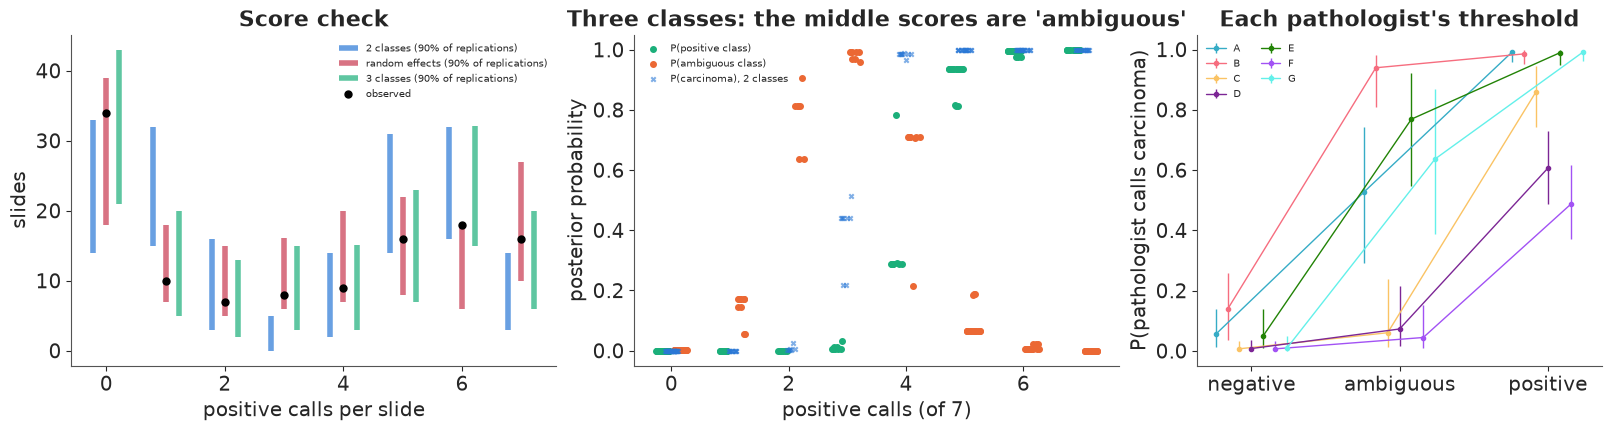

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), width_ratios=[1.2, 1.2, 1])
for k, (sh, col, lab) in enumerate([(sh_ci, BLUE, "2 classes"), (sh_re, RED, "random effects"),
                                    (sh_lc3, AQUA, "3 classes")]):
    lo, hi = np.quantile(sh, [0.05, 0.95], axis=0)
    xs = np.arange(J + 1) + (k - 1) * 0.22
    axes[0].vlines(xs, lo, hi, color=col, lw=4, alpha=0.7, label=f"{lab} (90% of replications)")
axes[0].scatter(np.arange(J + 1), obs_score, color="k", zorder=3, s=25, label="observed")
axes[0].set(xlabel="positive calls per slide", ylabel="slides", title="Score check")
axes[0].legend(fontsize=7)
pc = idata_lc3.posterior["p_cls"].mean(("chain", "draw")).to_numpy()
axes[1].scatter(k_pos + jit - 0.15, pc[:, 2], s=16, color=AQUA, label="P(positive class)")
axes[1].scatter(k_pos + jit + 0.15, pc[:, 1], s=16, color=ORANGE, label="P(ambiguous class)")
axes[1].scatter(k_pos + jit, p_by_score(idata_ci), s=10, color=BLUE, marker="x", alpha=0.6,
                label="P(carcinoma), 2 classes")
axes[1].set(xlabel="positive calls (of 7)", ylabel="posterior probability",
            title="Three classes: the middle scores are 'ambiguous'")
axes[1].legend(fontsize=7)
for j in range(J):
    lo, mid, hi = np.quantile(rate_d[:, j, :], [0.05, 0.5, 0.95], axis=0)
    axes[2].errorbar(np.arange(3) + (j - 3) * 0.08, mid, yerr=[mid - lo, hi - mid], marker="o",
                     ms=3, lw=1, capsize=0, label=RATERS[j])
axes[2].set_xticks(range(3), CLS)
axes[2].set(ylabel="P(pathologist calls carcinoma)", title="Each pathologist's threshold")
axes[2].legend(fontsize=7, ncol=2);

The three-class model keeps the meaning of the classes: slides with 0-1 positive calls are
negative, slides with 5-7 are positive, and slides with 2-4 positive calls are mostly
**ambiguous**. The right panel shows why pathologists disagree so much: on clearly negative and
clearly positive slides they nearly all agree (except that D and F still miss a fair share of the
positive class), and on ambiguous slides their calls spread from about 0.06 (F) to over 0.9 (B):
**the disagreement is a difference in thresholds on hard slides**, not random error.

What is the "sensitivity" of pathologist F? It depends on whether an ambiguous slide counts as
carcinoma - a clinical definition, not something the data can settle. The model makes the
question explicit instead of hiding it.

---
# 6 · When can the data answer at all?

## 6.1 · Counting parameters and degrees of freedom

A latent class model is only identifiable if the pattern table has at least as many free cells
as the model has parameters (necessary, not sufficient):

In [16]:
rows = []
for R_ in range(1, 8):
    rows.append({"raters": R_, "df = 2^R - 1": 2**R_ - 1, "2 classes: 2R + 1": 2 * R_ + 1,
                 "3 classes: 3R + 2": 3 * R_ + 2, "2 classes + RE: 2R + 2": 2 * R_ + 2})
ident = pd.DataFrame(rows).set_index("raters")
ident

,df = 2^R - 1,2 classes: 2R + 1,3 classes: 3R + 2,2 classes + RE: 2R + 2
raters,,,,
1,1,3,5,4
2,3,5,8,6
3,7,7,11,8
4,15,9,14,10
5,31,11,17,12
6,63,13,20,14
7,127,15,23,16


With **two** raters the two-class model has 5 parameters and the data 3 degrees of freedom: no
amount of data identifies the prevalence or the accuracies. Three raters are just identified;
three classes need four raters (15 >= 14), and so does the random-effects model (15 >= 10).

**Hui & Walter (1980)** found the classic escape for two tests: apply them in **two
populations with different prevalence**, assuming each test's sensitivity and specificity are
the same in both. Then there are $2 \times 3 = 6$ degrees of freedom and
$2 + 2 + 2 = 6$ parameters. Just identified - *if* the prevalences differ. We test this on
simulated data where the truth is known.

## 6.2 · Hui-Walter, simulated

Two tests with Se = (0.90, 0.75) and Sp = (0.95, 0.98), 400 subjects per population. Scenario 1:
prevalences 0.15 and 0.50. Scenario 2: both 0.30.

In [17]:
SE_T, SP_T, NG = np.array([0.90, 0.75]), np.array([0.95, 0.98]), 400


def simulate_hw(prevs, seed):
    g = np.random.default_rng(seed)
    grp = np.repeat(np.arange(2), NG)
    Dh = g.random(2 * NG) < np.asarray(prevs)[grp]
    Yh = (g.random((2 * NG, 2)) < np.where(Dh[:, None], SE_T, 1 - SP_T)).astype(int)
    return grp, Yh


def hui_walter(grp, Yh):
    with pm.Model(coords={"test": ["test 1", "test 2"], "pop": ["pop 1", "pop 2"]}) as m:
        prev = pm.Beta("prev", 1.0, 1.0, dims="pop")
        fpr = pm.Beta("fpr", 1.0, 1.0, dims="test")
        se = pm.Deterministic("se", fpr + (1 - fpr) * pm.Beta("u", 1.0, 1.0, dims="test"), dims="test")
        pm.Deterministic("sp", 1 - fpr, dims="test")
        l1 = pt.log(prev[grp]) + (Yh * pt.log(se) + (1 - Yh) * pt.log1p(-se)).sum(axis=1)
        l0 = pt.log1p(-prev[grp]) + (Yh * pt.log(fpr) + (1 - Yh) * pt.log1p(-fpr)).sum(axis=1)
        pm.Potential("lik", pt.logaddexp(l1, l0).sum())
    return m


hw = {}
for label, prevs in [("prevalences 0.15 / 0.50", (0.15, 0.50)), ("prevalences 0.30 / 0.30", (0.30, 0.30))]:
    with hui_walter(*simulate_hw(prevs, seed=5)):
        hw[label] = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.95)
    print(f"{label}: {diag(hw[label], ['prev', 'se', 'sp'])}")
    print(f"   Se test 1 90%: {q(draws(hw[label], 'se')[:, 0])[[0, 2]]} (truth 0.90); "
          f"Se test 2: {q(draws(hw[label], 'se')[:, 1])[[0, 2]]} (0.75); "
          f"prevalence pop 1: {q(draws(hw[label], 'prev')[:, 0])[[0, 2]]}")

prevalences 0.15 / 0.50: divergences 0, max r_hat 1.005, min bulk ESS 1168
   Se test 1 90%: [0.87  0.967] (truth 0.90); Se test 2: [0.744 0.871] (0.75); prevalence pop 1: [0.115 0.195]


prevalences 0.30 / 0.30: divergences 0, max r_hat 1.003, min bulk ESS 783
   Se test 1 90%: [0.823 0.992] (truth 0.90); Se test 2: [0.717 0.983] (0.75); prevalence pop 1: [0.218 0.361]


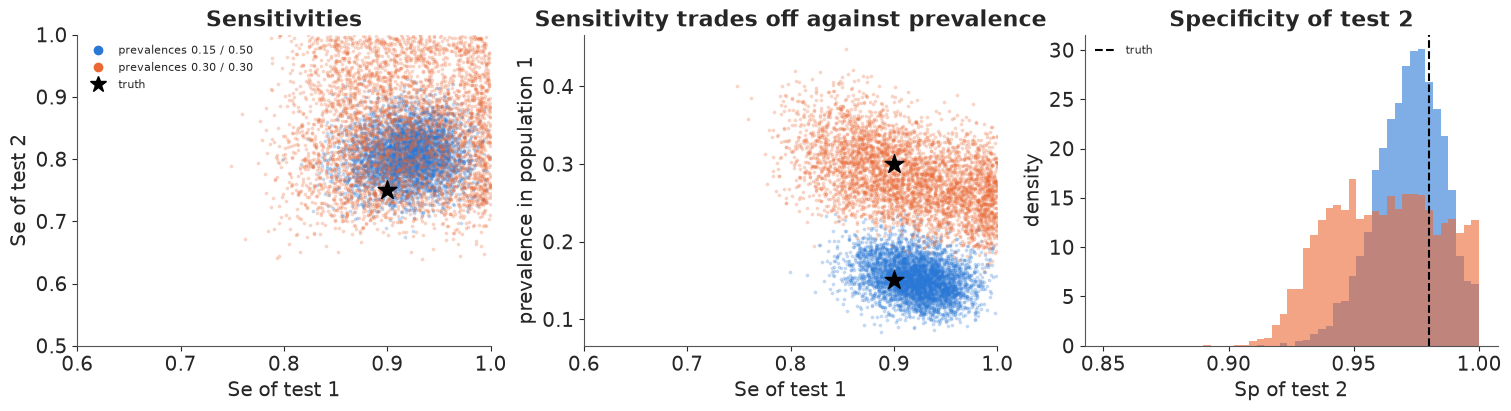

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for (label, idt), col in zip(hw.items(), [BLUE, ORANGE]):
    se1, se2, pv = draws(idt, "se")[:, 0], draws(idt, "se")[:, 1], draws(idt, "prev")[:, 0]
    axes[0].scatter(se1, se2, s=3, alpha=0.2, color=col, label=label)
    axes[1].scatter(se1, pv, s=3, alpha=0.2, color=col)
    axes[2].hist(draws(idt, "sp")[:, 1], bins=np.linspace(0.85, 1, 50), alpha=0.6, color=col,
                 density=True)
axes[0].scatter([SE_T[0]], [SE_T[1]], marker="*", s=200, color="k", label="truth")
axes[1].scatter([SE_T[0]], [0.15], marker="*", s=200, color="k")
axes[1].scatter([SE_T[0]], [0.30], marker="*", s=200, color="k")
axes[2].axvline(SP_T[1], color="k", ls="--", label="truth")
axes[0].set(xlabel="Se of test 1", ylabel="Se of test 2", xlim=(0.6, 1), ylim=(0.5, 1),
            title="Sensitivities")
axes[1].set(xlabel="Se of test 1", ylabel="prevalence in population 1", xlim=(0.6, 1),
            title="Sensitivity trades off against prevalence")
axes[2].set(xlabel="Sp of test 2", ylabel="density", title="Specificity of test 2")
from matplotlib.lines import Line2D
axes[0].legend(handles=[Line2D([], [], ls="", marker="o", color=c, label=l) for c, l in
                        zip([BLUE, ORANGE], hw)] + [Line2D([], [], ls="", marker="*", ms=12,
                                                           color="k", label="truth")], fontsize=8)
axes[2].legend(fontsize=8);

With different prevalences the posterior concentrates around the truth (Se of test 1: 90%
interval 0.87-0.97; the prevalence of population 1: 0.12-0.20 around a true 0.15). With equal
prevalences the two populations are one population, the model has 5 parameters for 3 degrees of
freedom, and the posterior is much wider, piles up against Se = 1 and Sp = 1, and trades
sensitivity against prevalence (middle panel). It does not spread over everything: the
"better than chance" constraint and the 0-1 bounds confine it - partial identification. The
sampler reports no problem in either case: diagnostics check the *computation*, not whether the
question was answerable.
(Hui-Walter's assumption that accuracy is the same in both populations is itself untestable in
the just-identified design; with a third test or population it becomes checkable.)

## 6.3 · Two pathologists: what informative priors buy

Back to real data. Suppose only pathologists A and C had read the slides. Two raters, 3 degrees
of freedom, 5 parameters: two equations short. What do we learn about the prevalence of
carcinoma?

* (a) with the vague "better than chance" priors used so far;
* (b) with two informative priors, **A's sensitivity** ~ Beta(38, 2) (mean 0.95) and **C's
  specificity** ~ Beta(49, 1) (mean 0.98), as a lab might have from validation studies;
* (c) with two informative priors on **one** pathologist, A's sensitivity ~ Beta(38, 2) and
  A's specificity ~ Beta(35, 5) (mean 0.875).

The values are illustrative, chosen close to what the seven-rater model says about A and C, so
that we can see whether the two-rater analysis gets back to the seven-rater answer.

A + C only, (a) vague: divergences 0, max r_hat 1.011, min bulk ESS 712; prevalence mean 0.47, 90% [0.354 0.585]


A + C only, (b) Se of A + Sp of C: divergences 0, max r_hat 1.005, min bulk ESS 810; prevalence mean 0.47, 90% [0.356 0.59 ]


A + C only, (c) Se and Sp of A: divergences 0, max r_hat 1.002, min bulk ESS 1801; prevalence mean 0.50, 90% [0.397 0.591]
all seven, 2-class model: prevalence 90% [0.442 0.609]
observed: A calls 0.56 of slides positive, C 0.38; C positive but A negative on 0.000


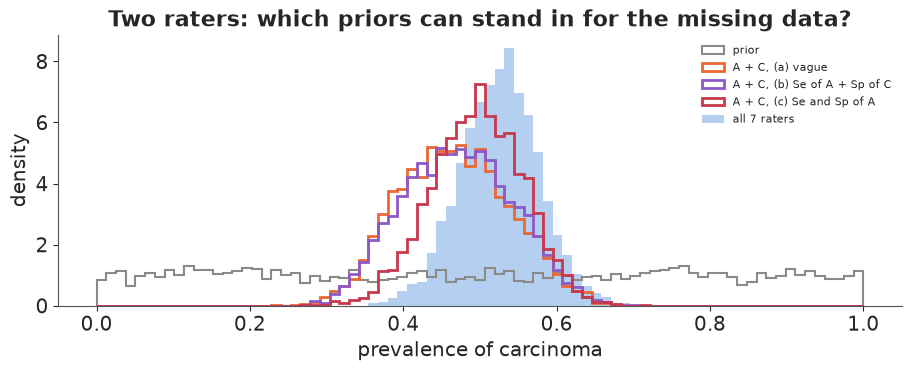

In [19]:
sub = [RATERS.index("A"), RATERS.index("C")]
two = {}
for label, kw in [("(a) vague", {}),
                  ("(b) Se of A + Sp of C", {"youden": False, "se_prior": {0: (38.0, 2.0)},
                                             "sp_prior": {1: (49.0, 1.0)}}),
                  ("(c) Se and Sp of A", {"youden": False, "se_prior": {0: (38.0, 2.0)},
                                          "sp_prior": {0: (35.0, 5.0)}})]:
    with lcm2(Y[:, sub], **kw):
        two[label] = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.95)
    print(f"A + C only, {label}: {diag(two[label], ['pi', 'se', 'sp'])}; "
          f"prevalence mean {draws(two[label], 'pi').mean():.2f}, 90% {q(draws(two[label], 'pi'))[[0, 2]]}")
print(f"all seven, 2-class model: prevalence 90% {q(draws(idata_ci, 'pi'))[[0, 2]]}")
print(f"observed: A calls {Y[:, sub[0]].mean():.2f} of slides positive, C {Y[:, sub[1]].mean():.2f}; "
      f"C positive but A negative on {np.mean((Y[:, sub[1]] == 1) & (Y[:, sub[0]] == 0)):.3f}")

fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.linspace(0, 1, 80)
ax.hist(np.random.default_rng(0).beta(1, 1, 4000), bins=bins, density=True, histtype="step",
        color=GREY, lw=1.5, label="prior")
for (label, idt), col in zip(two.items(), [ORANGE, PURPLE, RED]):
    ax.hist(draws(idt, "pi"), bins=bins, density=True, histtype="step", lw=2, color=col,
            label=f"A + C, {label}")
ax.hist(draws(idata_ci, "pi"), bins=bins, density=True, alpha=0.35, color=BLUE, label="all 7 raters")
ax.set(xlabel="prevalence of carcinoma", ylabel="density",
       title="Two raters: which priors can stand in for the missing data?")
ax.legend(fontsize=8);

Three lessons, none of which a sampler diagnostic would reveal (all three fits are clean):

1. **Vague priors do not give "anything goes".** The prevalence is confined to roughly
   0.35-0.59. This is *partial identification*: C never calls a slide positive that A calls
   negative, and if both are better than chance the prevalence lies roughly between C's positive
   rate (0.38, reached if C is perfectly specific) and A's (0.56, if A is perfectly sensitive).
   The data identify the bounds; where the posterior sits between them comes from the prior.
2. **An informative prior helps only if it bears on the unidentified direction.** Priors saying
   that A is very sensitive and C very specific (b) change nothing: they merely confirm that the
   edges of the bounds are plausible.
3. **Priors on both accuracies of one rater** (c) pin the prevalence through
   $\pi = (P(A+) - \mathrm{fpr}_A)/(\mathrm{Se}_A - \mathrm{fpr}_A)$ and shift it toward the
   seven-rater answer (mean 0.50 vs 0.47 with vague priors; 0.53 with all seven raters), cutting
   off the low end of the bounds (5% quantile 0.40 vs 0.35). What width remains comes from 118
   slides and from the prior's own width. The narrowing is the prior's doing: a different validation study would give a different
   answer from the same data, and it must be reported as an assumption, not a finding.

---
# 7 · More than two categories: Dawid & Skene's anaesthetists

## 7.1 · Data

Dawid & Skene (1979) introduced the EM algorithm for this problem with 45 patients whose
fitness for anaesthesia five anaesthetists rated on a 4-point scale from a standard form.
Anaesthetist 1 rated every form **three times**, weeks apart.

In [20]:
data.describe("anesthesia_dawid_skene")
an = data.load("anesthesia_dawid_skene")
item, rater, lab = an["item"].to_numpy() - 1, an["rater"].to_numpy() - 1, an["rating"].to_numpy() - 1
I_A, J_A, K_A = item.max() + 1, rater.max() + 1, 4
counts = np.zeros((I_A, K_A))
np.add.at(counts, (item, lab), 1)                        # votes per patient and category
print(pd.crosstab(an.rater, an.rating, margins=True))
r1 = np.stack([lab[(item == i) & (rater == 0)] for i in range(I_A)])   # anaesthetist 1, 3 readings
print(f"anaesthetist 1 gave the same rating on all three readings for {np.mean(r1.min(1) == r1.max(1)):.0%} "
      f"of patients")
mv_a = counts.argmax(axis=1)
ties = (counts == counts.max(axis=1, keepdims=True)).sum(axis=1) > 1
print(f"majority vote (7 ratings per patient): ties for patients {(np.where(ties)[0] + 1).tolist()}")

anesthesia_dawid_skene: Pre-operative assessments of 45 patients by 5 anaesthetists on a 4-point ordinal scale of pre-operative health, made from a standard form; anaesthetist 1 assessed every form three times weeks apart, the others once (315 ratings). Long format: item (patient, 1-45), rater (1-5), rating (1-4).
  source: Dawid & Skene (1979), Applied Statistics 28:20-28, Table 1; distributed as `anesthesia` in the CRAN package rater (Pullin, Gurrin & Vukcevic; GPL-2; the URL). CONVERTED from the .rda with R - keep the CSV in data/. An independent transcription (github.com/dallascard/dawid_skene) differs in one reading (patient 7, anaesthetist 1: 1,1,2 here vs 1,2,2).
  url:    https://raw.githubusercontent.com/cran/rater/master/data/anesthesia.rda
rating    1    2   3   4  All
rater                        
1        53   60  18   4  135
2        16   15  11   3   45
3        20   17   5   3   45
4        18   17   7   3   45
5        21   15   7   2   45
All     128  124  48  15  315

Category 4 is rare (15 of 315 ratings), and anaesthetist 1 disagrees with **himself** on 29% of
the patients - repeated reading is a rater effect of its own.

## 7.2 · The Dawid-Skene model with pooled confusion matrices

Each rater $j$ has a **confusion matrix** $\theta_j$: row $k$ is the distribution of the rating
the rater gives to a patient whose true category is $k$. Given the true category, ratings are
independent (including anaesthetist 1's three readings, an assumption we check below). The true
category is summed out:

$$p(\text{ratings of } i) = \sum_{k=1}^{4} \pi_k \prod_{r \in \text{ratings of } i}
  \theta_{j[r],\, k,\, y_r}.$$

Each row of each confusion matrix is a 4-simplex, 80 probabilities for 5 raters, from 315
ratings. Rare true categories get very few ratings, so we **pool across raters**: rows are
logistic-normal around a shared population confusion matrix,

$$\theta_{jk\cdot} = \operatorname{softmax}(\mu_{k\cdot} + \tau z_{jk\cdot}), \quad
  z \sim \mathcal N(0, 1), \quad \mu_{kl} \sim \mathcal N(2.5\,[k = l],\, 1.5^2), \quad
  \tau \sim \mathrm{HalfNormal}(1).$$

The prior mean of $\mu$ favours the diagonal (a rater usually reports the true category): that is
the K-category version of "better than chance", and it breaks the $4! = 24$-fold label symmetry.
$\tau \to 0$ means all anaesthetists share one confusion matrix; large $\tau$ means no pooling.
For comparison, an **unpooled** version gives every row its own $\mathcal N(2.5[k = l], 1.5^2)$
logits, and **EM** gives the maximum likelihood estimate.

In [21]:
M_A = np.zeros((I_A, len(an)))
M_A[item, np.arange(len(an))] = 1.0                       # sums ratings into patients


def dawid_skene(M, rater_, lab_, n_items, pooled=True):
    coords = {"item": np.arange(1, n_items + 1), "rater": np.arange(1, J_A + 1),
              "true": np.arange(1, K_A + 1), "rated": np.arange(1, K_A + 1)}
    with pm.Model(coords=coords) as m:
        pi_ = pm.Dirichlet("pi", np.ones(K_A), dims="true")
        prior_mu = 2.5 * np.eye(K_A)
        if pooled:
            mu = pm.Normal("mu", prior_mu, 1.5, dims=("true", "rated"))
            tau = pm.HalfNormal("tau", 1.0)
            z = pm.Normal("z", 0.0, 1.0, dims=("rater", "true", "rated"))
            eta = mu[None] + tau * z
        else:
            eta = pm.Normal("eta", np.broadcast_to(prior_mu, (J_A, K_A, K_A)), 1.5,
                            dims=("rater", "true", "rated"))
        log_theta = eta - pt.logsumexp(eta, axis=-1, keepdims=True)
        pm.Deterministic("theta", pt.exp(log_theta), dims=("rater", "true", "rated"))
        L = pt.log(pi_)[None] + pt.dot(M, log_theta[rater_, :, lab_])     # (item, true)
        ll = pt.logsumexp(L, axis=1)
        pm.Potential("lik", ll.sum())
        pm.Deterministic("ll", ll, dims="item")
        pm.Deterministic("p_true", pt.exp(L - ll[:, None]), dims=("item", "true"))
    return m


ds_fits = {}
for label, pooled in [("pooled", True), ("unpooled", False)]:
    t0 = time.time()
    with dawid_skene(M_A, rater, lab, I_A, pooled):
        ds_fits[label] = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9)
    print(f"{label}: {time.time() - t0:.0f} s; {diag(ds_fits[label], ['pi', 'theta'])}")
print(f"between-rater sd tau: {q(draws(ds_fits['pooled'], 'tau'))}")

pooled: 2 s; divergences 0, max r_hat 1.004, min bulk ESS 1919


unpooled: 2 s; divergences 0, max r_hat 1.003, min bulk ESS 1069
between-rater sd tau: [0.081 0.376 0.711]


In [22]:
def em_ds(iters=500):
    T = counts / counts.sum(axis=1, keepdims=True)           # start from vote shares
    for _ in range(iters):
        pi_ = T.mean(axis=0)
        th = np.full((J_A, K_A, K_A), 1e-12)
        for r_, i_, l_ in zip(rater, item, lab):
            th[r_, :, l_] += T[i_]
        th /= th.sum(axis=2, keepdims=True)
        logT = np.log(pi_)[None] + M_A @ np.log(th[rater, :, lab])
        T = np.exp(logT - special.logsumexp(logT, axis=1, keepdims=True))
    return pi_, th, T


pi_em_a, th_em, T_em = em_ds()
print("prevalence of true categories 1-4:")
print(pd.DataFrame({"EM": pi_em_a, "unpooled": draws(ds_fits["unpooled"], "pi").mean(axis=0),
                    "pooled": draws(ds_fits["pooled"], "pi").mean(axis=0)},
                   index=[1, 2, 3, 4]).round(3).T)
print(f"EM confusion entries that are exactly 0 (< 1e-6): {(th_em < 1e-6).sum()} of {th_em.size}")

prevalence of true categories 1-4:
              1      2      3      4
EM        0.400  0.422  0.112  0.067
unpooled  0.392  0.440  0.119  0.049
pooled    0.394  0.432  0.133  0.042
EM confusion entries that are exactly 0 (< 1e-6): 38 of 80


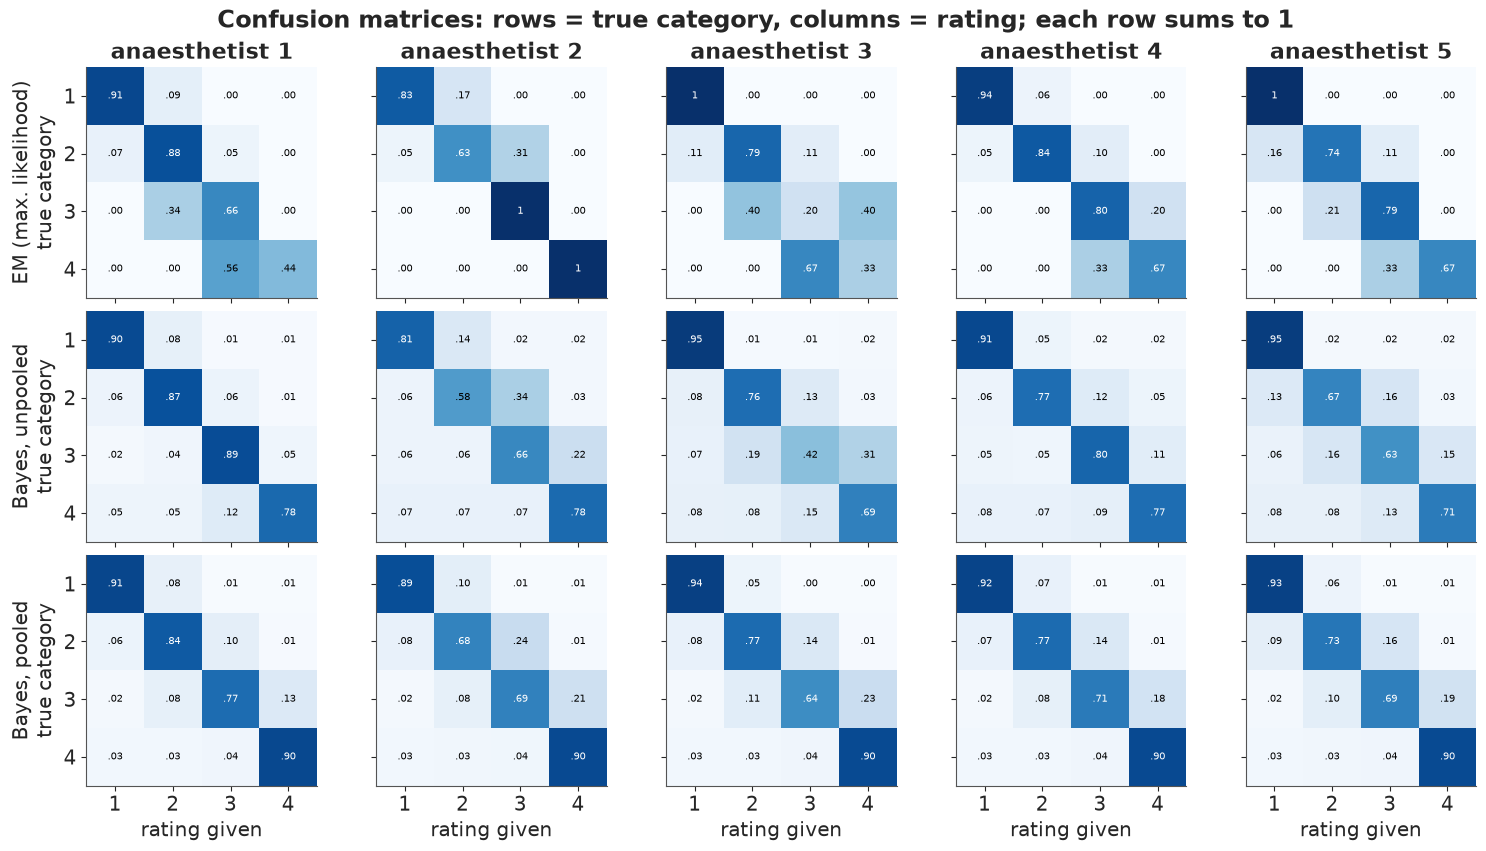

In [23]:
th_pool = draws(ds_fits["pooled"], "theta").mean(axis=0)
th_unp = draws(ds_fits["unpooled"], "theta").mean(axis=0)
fig, axes = plt.subplots(3, J_A, figsize=(15, 8.4), sharex=True, sharey=True)
for row, (th, lab_row) in enumerate([(th_em, "EM (max. likelihood)"), (th_unp, "Bayes, unpooled"),
                                     (th_pool, "Bayes, pooled")]):
    for j in range(J_A):
        ax = axes[row, j]
        ax.imshow(th[j], cmap="Blues", vmin=0, vmax=1)
        for k in range(K_A):
            for l in range(K_A):
                ax.text(l, k, "1" if th[j, k, l] >= 0.995 else f"{th[j, k, l]:.2f}"[1:], ha="center",
                        va="center", fontsize=7, color="w" if th[j, k, l] > 0.6 else "k")
        ax.set_xticks(range(K_A), range(1, K_A + 1))
        ax.set_yticks(range(K_A), range(1, K_A + 1))
        if row == 0:
            ax.set_title(f"anaesthetist {j + 1}")
        if j == 0:
            ax.set_ylabel(f"{lab_row}\ntrue category")
        if row == 2:
            ax.set_xlabel("rating given")
fig.suptitle("Confusion matrices: rows = true category, columns = rating; each row sums to 1");

EM fits each confusion row from whatever patients happen to be in that category. For the rare
true categories rows are 0s and 1s (anaesthetist 2 "always" rates a category-3 patient 3,
anaesthetist 3 "always" rates a category-1 patient 1), and 38 of the 80 entries are exactly zero -
"never" from a handful of patients. The unpooled Bayesian fit keeps every entry away from 0 and 1;
its row 4, estimated from about two patients, says little beyond the prior. The pooled fit
borrows across anaesthetists: the between-rater sd $\tau$ is modest (posterior median 0.38 on the
logit scale, 90% interval 0.08-0.71), so the five matrices are pulled toward one shared pattern.
Row 4 is then essentially the same for everyone (0.90 on the diagonal) - an honest reading is that
**the data say almost nothing about how each anaesthetist rates the sickest patients**; the
pooled model reports the shared matrix, which itself leans on the diagonal-favouring prior. The
common structure is sensible for an ordinal scale: errors are mostly to an **adjacent** category.

## 7.3 · Checks

Two predictive checks aimed at the model's assumptions: the agreement of each pair of raters,
and anaesthetist 1's **self-agreement** across his three readings (conditional independence
says repeated readings of the same form are independent given the truth, which a rater who
remembers the form would violate).

In [24]:
def replicate_ds(idata, M_items, rater_, n_items, n_rep=1000, seed=3):
    g = np.random.default_rng(seed)
    pi_d_, th_d = draws(idata, "pi"), draws(idata, "theta")
    idx_ = g.choice(len(pi_d_), n_rep, replace=False)
    true = (g.random((n_rep, n_items, 1)) > np.cumsum(pi_d_[idx_], axis=1)[:, None, :]).sum(axis=2)
    true_r = true[:, M_items]                                 # (rep, ratings)
    probs = th_d[idx_][np.arange(n_rep)[:, None], rater_[None, :], true_r]   # (rep, ratings, K)
    return (g.random(probs.shape[:2] + (1,)) > np.cumsum(probs, axis=2)).sum(axis=2), true


item_of = item
lab_rep, _ = replicate_ds(ds_fits["pooled"], item_of, rater, I_A)


def ds_stats(labs):
    """(..., ratings) -> anaesthetist 1 self-agreement and mean pairwise agreement of raters 2-5."""
    labs = np.atleast_2d(labs)
    r1_ = np.stack([labs[:, (item == i) & (rater == 0)] for i in range(I_A)], axis=1)
    self_agree = (r1_.min(axis=2) == r1_.max(axis=2)).mean(axis=1)
    single = np.stack([np.stack([labs[:, (item == i) & (rater == j)][:, 0] for i in range(I_A)], 1)
                       for j in range(1, J_A)], axis=2)       # (rep, item, rater 2-5)
    pa = np.stack([(single[..., a] == single[..., b]).mean(axis=1)
                   for a, b in combinations(range(J_A - 1), 2)], axis=1)
    return self_agree, pa


sa_obs, pa_obs = ds_stats(lab)
sa_rep, pa_rep = ds_stats(lab_rep)
print(f"anaesthetist 1 self-agreement: observed {sa_obs[0]:.2f}, replicated 90% "
      f"{q(sa_rep)[[0, 2]]}, P(rep >= obs) = {np.mean(sa_rep >= sa_obs[0]):.2f}")
zp = (pa_obs[0] - pa_rep.mean(axis=0)) / pa_rep.std(axis=0)
print("pairwise agreement of anaesthetists 2-5, z-scores (obs - rep):", zp.round(2))

anaesthetist 1 self-agreement: observed 0.71, replicated 90% [0.511 0.8  ], P(rep >= obs) = 0.31
pairwise agreement of anaesthetists 2-5, z-scores (obs - rep): [-0.36  0.44 -0.3  -0.3   0.37  0.07]


Anaesthetist 1 agrees with himself about as often as the model predicts for three independent
readings, so there is no sign that he remembered the forms, and the pairwise agreements among
the other four fall within the replicated range. With 45 patients these checks can only catch
large violations.

## 7.4 · The patients: majority vote vs the model

In [25]:
p_true = ds_fits["pooled"].posterior["p_true"].mean(("chain", "draw")).to_numpy()
p_unp = ds_fits["unpooled"].posterior["p_true"].mean(("chain", "draw")).to_numpy()
model_lab = p_true.argmax(axis=1)
disagree = np.where((model_lab != mv_a) | ties)[0]
unsure = np.where(p_true.max(axis=1) < 0.9)[0]
print(f"patients where the pooled model's most probable category differs from majority vote or MV "
      f"ties: {(disagree + 1).tolist()}")
print(f"patients with max posterior probability < 0.9: {(unsure + 1).tolist()}")
print(f"pooled vs unpooled most-probable category differ for {int((p_unp.argmax(1) != model_lab).sum())} patients")
show = np.union1d(disagree, unsure)
print(pd.DataFrame(np.column_stack([counts[show].astype(int), p_true[show].round(2)]),
                   index=[f"patient {i + 1}" for i in show],
                   columns=[f"votes {k}" for k in range(1, 5)] + [f"P(true={k})" for k in range(1, 5)]))
for i in disagree:
    print(f"patient {i + 1}: ratings by anaesthetist", {j + 1: (lab[(item == i) & (rater == j)] + 1).tolist()
                                                        for j in range(J_A)})

patients where the pooled model's most probable category differs from majority vote or MV ties: [12, 38]
patients with max posterior probability < 0.9: [3, 12, 38]
pooled vs unpooled most-probable category differ for 0 patients
            votes 1  votes 2  votes 3  votes 4  P(true=1)  P(true=2)  \
patient 3       3.0      4.0      0.0      0.0       0.29       0.71   
patient 12      0.0      3.0      3.0      1.0       0.00       0.68   
patient 38      0.0      3.0      4.0      0.0       0.00       0.75   

            P(true=3)  P(true=4)  
patient 3        0.00        0.0  
patient 12       0.32        0.0  
patient 38       0.25        0.0  
patient 12: ratings by anaesthetist {1: [2, 2, 2], 2: [3], 3: [3], 4: [4], 5: [3]}
patient 38: ratings by anaesthetist {1: [2, 3, 2], 2: [3], 3: [2], 4: [3], 5: [3]}


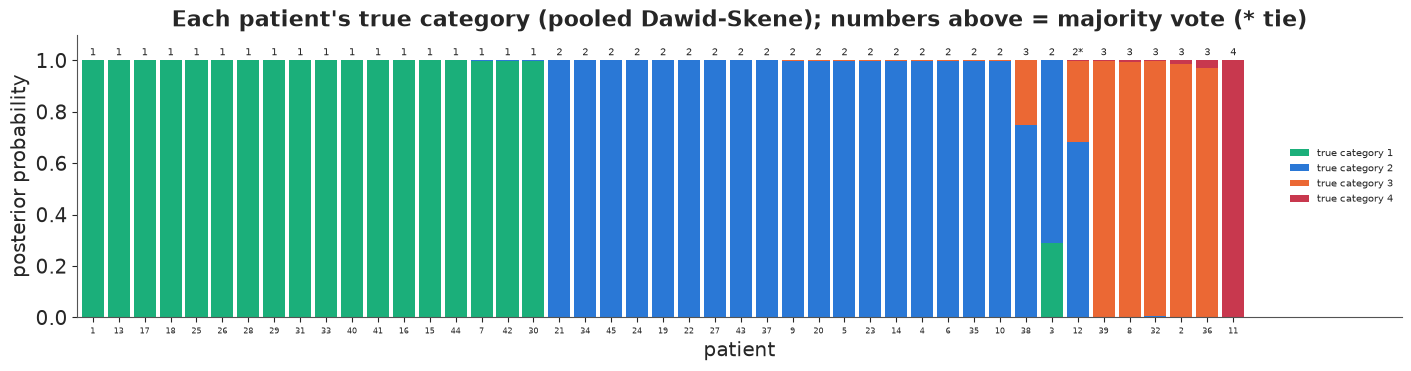

In [26]:
fig, ax = plt.subplots(figsize=(14, 3.6))
ordr = np.lexsort((-p_true.max(axis=1), model_lab))
cols4 = [AQUA, BLUE, ORANGE, RED]
bottom = np.zeros(I_A)
for k in range(K_A):
    ax.bar(np.arange(I_A), p_true[ordr, k], bottom=bottom, color=cols4[k], width=0.85,
           label=f"true category {k + 1}")
    bottom += p_true[ordr, k]
for x, i in enumerate(ordr):
    ax.text(x, 1.02, str(mv_a[i] + 1) + ("*" if ties[i] else ""), ha="center", fontsize=7)
ax.set_xticks(np.arange(I_A), ordr + 1, fontsize=6)
ax.set(xlabel="patient", ylabel="posterior probability", ylim=(0, 1.1), xlim=(-0.6, I_A + 5.5),
       title="Each patient's true category (pooled Dawid-Skene); numbers above = majority vote (* tie)")
ax.legend(fontsize=7, loc="center right");

For 42 of the 45 patients the model and the majority agree and the model is at least 90% sure.
Three patients are genuinely split between adjacent categories. Patient 12 is a majority-vote
tie (anaesthetist 1 said 2 three times; three others said 3 and one said 4); patient 38 has four
votes for 3 and three for 2, yet the model prefers 2 (0.75). Both times it leans on anaesthetist
1, the most reliable rater for true category 2 (he rates such a patient 3 about 10% of the time;
anaesthetists 2, 4 and 5 do so 14-24% of the time). Majority vote counts his three readings as
three votes; the model counts them as three noisy readings by one rater. Pooled and unpooled fits
pick the same most probable category for every patient.

---
# 8 · A known-truth check (simulated)

Everything so far is inference about a truth we never see. To check that the machinery is
calibrated, simulate a dataset **from the fitted pooled model** with a known true category for
each of 600 patients, refit, and compare with the truth. With all seven ratings per patient
almost every patient is easy, so we simulate the cheaper design typical of crowdsourcing: each
patient is rated **once by three of the five anaesthetists**, chosen at random. We also score
majority vote.

In [27]:
N_SIM, PER = 600, 3
g = np.random.default_rng(8)
pi_true = draws(ds_fits["pooled"], "pi").mean(axis=0)
th_true = th_pool
true_sim = g.choice(K_A, N_SIM, p=pi_true)
item_s = np.repeat(np.arange(N_SIM), PER)
rater_s = np.concatenate([g.choice(J_A, PER, replace=False) for _ in range(N_SIM)])
lab_s = np.array([g.choice(K_A, p=th_true[r_, true_sim[i_]]) for i_, r_ in zip(item_s, rater_s)])
M_S = np.zeros((N_SIM, len(item_s)))
M_S[item_s, np.arange(len(item_s))] = 1.0
t0 = time.time()
with dawid_skene(M_S, rater_s, lab_s, N_SIM, pooled=True):
    idata_sim = pm.sample(random_seed=RANDOM_SEED, progressbar=False, target_accept=0.9)
print(f"{time.time() - t0:.0f} s; {diag(idata_sim, ['pi', 'theta'])}")

p_sim = idata_sim.posterior["p_true"].mean(("chain", "draw")).to_numpy()
cnt_s = np.zeros((N_SIM, K_A))
np.add.at(cnt_s, (item_s, lab_s), 1)
tie_s = (cnt_s == cnt_s.max(axis=1, keepdims=True)).sum(axis=1) > 1
mv_s = np.array([g.choice(np.flatnonzero(c == c.max())) for c in cnt_s])   # random tie-break
print(f"accuracy vs truth: model {np.mean(p_sim.argmax(1) == true_sim):.3f}, "
      f"majority vote {np.mean(mv_s == true_sim):.3f} (ties broken at random: {tie_s.sum()} patients)")
print(f"log score (mean log P(true label)): model {np.mean(np.log(p_sim[np.arange(N_SIM), true_sim])):.3f}")
th_sim = draws(idata_sim, "theta")
lo, hi = np.quantile(th_sim, [0.05, 0.95], axis=0)
print(f"confusion entries inside their 90% interval: {np.mean((th_true >= lo) & (th_true <= hi)):.0%} "
      f"of {th_true.size}")

4 s; divergences 0, max r_hat 1.002, min bulk ESS 1291
accuracy vs truth: model 0.948, majority vote 0.900 (ties broken at random: 23 patients)
log score (mean log P(true label)): model -0.158
confusion entries inside their 90% interval: 100% of 80


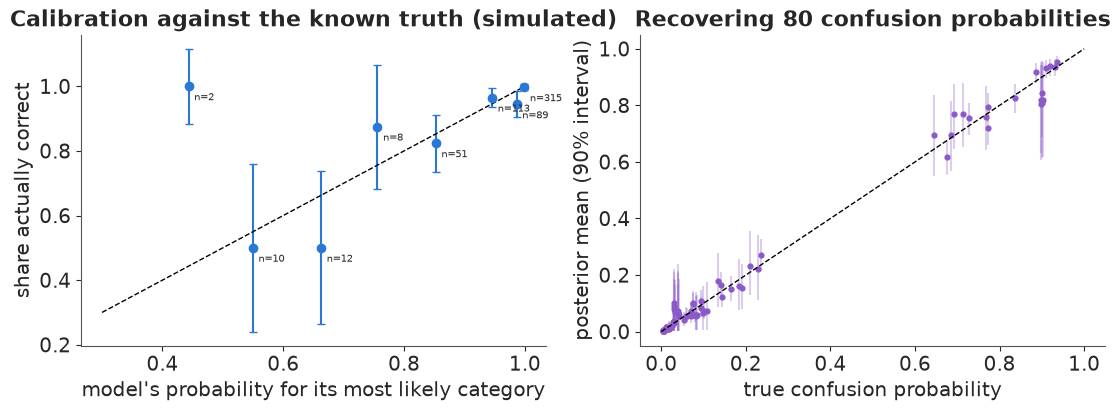

In [28]:
pmax = p_sim.max(axis=1)
correct = p_sim.argmax(axis=1) == true_sim
bins_c = np.array([0.3, 0.5, 0.6, 0.7, 0.8, 0.9, 0.97, 0.995, 1.0001])
which = np.digitize(pmax, bins_c) - 1
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for b_ in range(len(bins_c) - 1):
    sel = which == b_
    if sel.sum() > 0:
        m_, n_ = correct[sel].mean(), sel.sum()
        se_ = np.sqrt(max(m_ * (1 - m_), 0.01) / n_)
        axes[0].errorbar(pmax[sel].mean(), m_, yerr=1.64 * se_, fmt="o", color=BLUE, capsize=3)
        axes[0].annotate(f"n={n_}", (pmax[sel].mean(), m_), fontsize=7, xytext=(4, -10),
                         textcoords="offset points")
axes[0].plot([0.3, 1], [0.3, 1], color="k", lw=1, ls="--")
axes[0].set(xlabel="model's probability for its most likely category",
            ylabel="share actually correct", title="Calibration against the known truth (simulated)")
axes[1].scatter(th_true.ravel(), th_sim.mean(axis=0).ravel(), s=12, color=PURPLE)
axes[1].vlines(th_true.ravel(), lo.ravel(), hi.ravel(), color=PURPLE, alpha=0.3)
axes[1].plot([0, 1], [0, 1], color="k", lw=1, ls="--")
axes[1].set(xlabel="true confusion probability", ylabel="posterior mean (90% interval)",
            title="Recovering 80 confusion probabilities");

Three findings. First, the label probabilities are **calibrated** within binomial error: in
every bin the share correct is consistent with the stated probability (the bins below 0.8 hold
only 2-12 patients each, so this is a coarse check). Second, the model beats majority vote: 94.8%
vs 90.0% correct, with 23 majority-vote ties broken at random; reliability weighting matters most
exactly where the raters split. Third, all 80 true confusion probabilities lie inside their 90%
intervals - more than 90%, because pooling and the prior widen the intervals of rare rows. This is the check to repeat before trusting a latent class model
on a new problem: simulate from the fitted model with the real design and see what it recovers.
It checks the computation and the design, not the modelling assumptions - data simulated from the
model satisfy conditional independence by construction.

---
# 9 · Decisions for the carcinoma slides

## 9.1 · Which slides should an expert panel adjudicate?

Suppose each slide leads to one of two actions: **refer** (colposcopy and follow-up) or
**routine** screening. Illustrative losses (in units of one unnecessary referral):

| truth \ action | refer | routine |
|---|---|---|
| negative | 1 | 0 |
| ambiguous | 0 | 5 |
| positive | 0 | 20 |

An expert panel can review a slide and (we assume) determine its class, at a cost of 0.5 units.
With posterior class probabilities $p_i$ the best action without review has expected loss
$\min(p_{i,\text{neg}},\; 5 p_{i,\text{amb}} + 20 p_{i,\text{pos}})$; after a perfect review it
is 0. So that minimum is the **expected value of perfect information** for slide $i$: review it
when it exceeds the cost. We use the three-class model, and average the loss over its posterior.

In [29]:
LOSS = np.array([[1.0, 0.0], [0.0, 5.0], [0.0, 20.0]])    # rows: class; cols: refer, routine
COST_REVIEW = 0.5
pcls_d = draws(idata_lc3, "p_cls")                         # (S, item, cls)
pcls = pcls_d.mean(axis=0)
exp_loss = pcls @ LOSS                                      # (item, action)
action = exp_loss.argmin(axis=1)
evpi = exp_loss.min(axis=1)
review = evpi > COST_REVIEW
mv_action = np.where(mv == 1, 0, 1)
print(f"refer {int((action == 0).sum())} slides, routine {int((action == 1).sum())}; majority vote "
      f"would refer {int((mv_action == 0).sum())}")
print(f"slides worth an expert review (EVPI > {COST_REVIEW}): {int(review.sum())}; expected loss "
      f"without reviews {evpi.sum():.1f}, with them {evpi[~review].sum() + COST_REVIEW * review.sum():.1f}")
tab = pd.DataFrame({"pattern": ["".join(map(str, r)) for r in Y], "calls": k_pos,
                    "P(neg)": pcls[:, 0], "P(amb)": pcls[:, 1], "P(pos)": pcls[:, 2],
                    "action": np.where(action == 0, "refer", "routine"), "EVPI": evpi, "review": review})
patt_tab = (tab.groupby("pattern").agg(slides=("calls", "size"), calls=("calls", "first"),
                                       **{c: (c, "first") for c in ["P(neg)", "P(amb)", "P(pos)",
                                                                    "action", "EVPI", "review"]})
            .sort_values("EVPI", ascending=False))
print(patt_tab.round(3).head(10).to_string())

refer 80 slides, routine 38; majority vote would refer 59
slides worth an expert review (EVPI > 0.5): 8; expected loss without reviews 9.0, with them 6.6
         slides  calls  P(neg)  P(amb)  P(pos)   action   EVPI  review
pattern                                                               
0100000       6      1   0.828   0.172   0.000    refer  0.828    True
0000100       2      1   0.856   0.144   0.000  routine  0.719    True
1100000       2      2   0.362   0.637   0.000    refer  0.362   False
1000000       2      1   0.944   0.056   0.000  routine  0.278   False
0100100       4      2   0.187   0.813   0.000    refer  0.187   False
0100001       1      2   0.094   0.906   0.000    refer  0.094   False
1100100       2      3   0.019   0.970   0.011    refer  0.019   False
0000000      34      0   0.997   0.003   0.000  routine  0.013   False
1100001       1      3   0.007   0.960   0.032    refer  0.007   False
0100101       5      3   0.002   0.992   0.006    refer  0.002   

Majority vote refers the 59 slides with 4+ positive calls. The model refers 80: anything with a
real chance of being ambiguous or positive, because missing those is expensive. The slides worth
a review are *not* the 3-4 splits - the model is confident those are ambiguous and refers them
anyway - but the 8 slides on which a **single** liberal reader (B or E) called carcinoma: probably
negative (P about 0.83-0.86), with a 14-17% chance of an ambiguous lesion. Reviewing them cuts the
expected loss over all 118 slides from 9.0 to 6.6 units. Unanimous slides are never worth a review.

The list is only as good as the model. The random-effects model of section 5.1, which gives a
unanimously negative slide a 27% chance of carcinoma, would make every one of the 34 unanimous
negatives worth a review (routine would cost $20 \times 0.27$ in expectation, referral 0.73, so
a perfect review is worth 0.73 > 0.5). Choosing the latent class model is a clinical statement
about what "carcinoma" means, not only a statistical one.

## 9.2 · Which three pathologists to keep?

A lab can afford three readers per slide in future. Which three? For every one of the 35 panels,
compute from the three-class model the expected loss per slide of the best refer/routine rule
based on that panel's calls alone: enumerate the 8 call patterns, their probabilities under
each class, choose the Bayes action per pattern, and average over classes and posterior draws.
The answer depends on the loss table, so we compute it for two: the one above (missing an
ambiguous slide costs 5) and a "carcinoma only" table in which missing an ambiguous slide costs
no more than an unnecessary referral (1).

In [30]:
LOSSES = {"missed ambiguous = 5": LOSS,
          "missed ambiguous = 1": np.array([[1.0, 0.0], [0.0, 1.0], [0.0, 20.0]])}
w_d = draws(idata_lc3, "w")[::4]                            # thin draws: (S', cls)
r_d = rate_d[::4]                                          # (S', rater, cls)


def panel_loss(panel, loss):
    pats = np.array(np.meshgrid(*[[0, 1]] * len(panel), indexing="ij")).reshape(len(panel), -1).T
    rr = r_d[:, panel, :]                                  # (S', p, cls)
    lik = np.prod(np.where(pats[None, :, :, None] == 1, rr[:, None], 1 - rr[:, None]), axis=2)
    joint = lik * w_d[:, None, :]                          # (S', pattern, cls)
    rule = (joint.mean(axis=0) @ loss).argmin(axis=1)      # Bayes action per pattern
    return np.einsum("spc,pc->s", joint, loss[:, rule].T)  # expected loss per draw


panels = {}
for lname, loss in LOSSES.items():
    rows_ = []
    for panel in combinations(range(J), 3):
        ld = panel_loss(list(panel), loss)
        rows_.append(("".join(RATERS[j] for j in panel), ld.mean(), *np.quantile(ld, [0.05, 0.95])))
    res = pd.DataFrame(rows_, columns=["panel", "loss", "lo", "hi"]).sort_values("loss")
    single = pd.Series({RATERS[j]: panel_loss([j], loss).mean() for j in range(J)})
    no_info = (w_d.mean(axis=0) @ loss).min()              # best action with no reader at all
    full = panel_loss(list(range(J)), loss).mean()
    best = res.panel.iloc[0]
    ld_best = panel_loss([RATERS.index(c) for c in best], loss)
    p_beat = {p_: round(float(np.mean(ld_best < panel_loss([RATERS.index(c) for c in p_], loss))), 2)
              for p_ in res.panel.iloc[1:4]}
    panels[lname] = dict(res=res.reset_index(drop=True), single=single, no_info=no_info, full=full)
    print(f"[{lname}] no reader {no_info:.3f}, best single {single.idxmin()} {single.min():.3f}, "
          f"all seven {full:.3f} per slide")
    print("   best panels:", ", ".join(f"{r.panel} {r.loss:.3f}" for r in res.head(5).itertuples()),
          "| worst:", ", ".join(f"{r.panel} {r.loss:.3f}" for r in res.tail(3).itertuples()))
    print(f"   P(best panel {best} beats the next three):", p_beat)

[missed ambiguous = 5] no reader 0.373, best single B 0.290, all seven 0.066 per slide
   best panels: BEG 0.085, BCG 0.088, BFG 0.088, BDG 0.088, ABG 0.088 | worst: ADF 0.373, CDF 0.373, ACD 0.373
   P(best panel BEG beats the next three): {'BCG': 0.53, 'BFG': 0.51, 'BDG': 0.51}
[missed ambiguous = 1] no reader 0.373, best single G 0.182, all seven 0.022 per slide
   best panels: BEG 0.035, ABE 0.044, EFG 0.048, DEG 0.048, CEG 0.048 | worst: ACF 0.117, ADF 0.130, CDF 0.373
   P(best panel BEG beats the next three): {'ABE': 0.76, 'EFG': 0.82, 'DEG': 0.82}


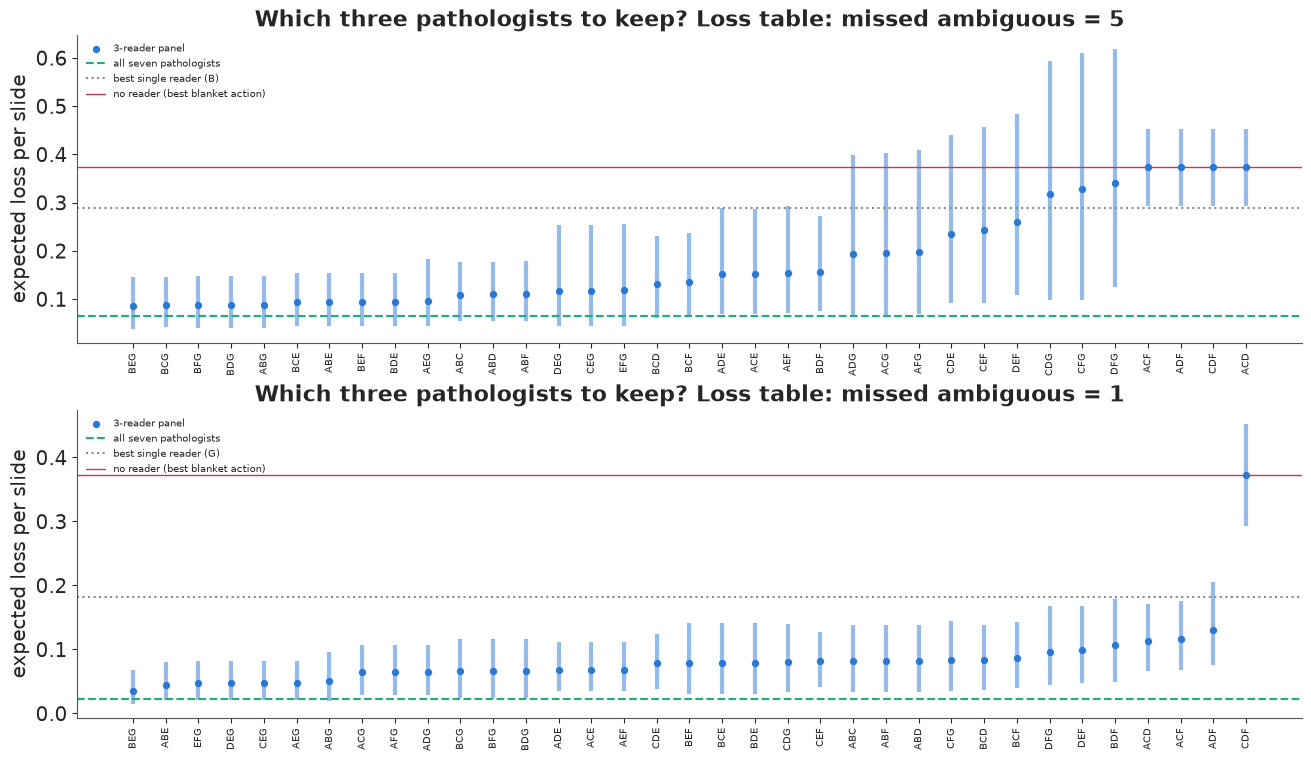

In [31]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7.5))
for ax, (lname, d_) in zip(axes, panels.items()):
    res = d_["res"]
    ax.vlines(np.arange(len(res)), res.lo, res.hi, color=BLUE, alpha=0.5, lw=3)
    ax.scatter(np.arange(len(res)), res.loss, color=BLUE, s=18, zorder=3, label="3-reader panel")
    ax.axhline(d_["full"], color=AQUA, ls="--", label="all seven pathologists")
    ax.axhline(d_["single"].min(), color=GREY, ls=":", label=f"best single reader ({d_['single'].idxmin()})")
    ax.axhline(d_["no_info"], color=RED, lw=1, label="no reader (best blanket action)")
    ax.set_xticks(np.arange(len(res)), res.panel, rotation=90, fontsize=7)
    ax.set(ylabel="expected loss per slide", title=f"Which three pathologists to keep? Loss table: {lname}")
    ax.legend(fontsize=7, loc="upper left");

The same three pathologists come out on top under both loss tables: **B, E and G**. They are
the readers who flag the ambiguous slides (they call them positive 92%, 76% and 64% of the time)
while rarely calling a clearly negative slide positive. With "missed ambiguous = 5" their panel
costs 0.085 per slide against 0.066 for all seven, but four other panels containing B and G are
within 0.003 and beat BEG in about half of the posterior draws: choose among them on cost or
availability. With "missed ambiguous = 1" the ranking is sharper (BEG beats the next panels in
76-82% of draws).

The conservative readers C, D and F are of little use for this decision: under the first loss
table the panels ACD, ACF, ADF and CDF are no better than referring every slide without looking,
because their "negative" calls cannot rule out an ambiguous lesion. What a rater is worth depends
on the decision, not only on an accuracy score.

---
## Summary

* **Majority vote** assumes equal, symmetric, certain raters. The latent class model replaces
  those assumptions with parameters: prevalence and per-rater sensitivity/specificity (or a full
  confusion matrix), with the true class **summed out with `logsumexp`**.
* **Identifiability first**: count degrees of freedom ($2^J - 1$) against parameters. Two
  binary raters identify only bounds, unless a second population has a different prevalence
  (Hui-Walter; shown on simulated data) or informative priors bear on the unidentified direction
  - in which case the conclusion belongs to the priors.
* **Label switching** is an exact symmetry. Mirrored chains gave a huge r_hat with zero
  divergences; a **"better than chance"** parameterisation ($\mathrm{Se} = \mathrm{fpr} + (1 -
  \mathrm{fpr})u$; ordered class logits; a diagonal-favouring confusion prior) removes it.
* **Conditional independence** failed a score / pairwise-agreement check on the carcinoma slides.
  A random-effects model fixed the fit (+20 nats LOO) but turned the class into something other
  than carcinoma (P = 0.27 for a slide nobody called positive); a **three-class** model with an
  "ambiguous" class fitted as well and kept its meaning. With no gold standard, fit is necessary
  but not sufficient: check what the latent class *means*.
* **Dawid-Skene** with **pooled confusion matrices** avoids EM's zeros and ones for rare
  categories, although for the rarest category the pooled matrix is mostly prior; checks on
  self-agreement and pairwise agreement passed; a simulation from the fitted model (three ratings
  per patient) showed calibrated label probabilities and 95% vs 90% accuracy over majority vote.
* **Decisions** use the posterior directly: the value of information ranks slides for expert
  review (lone positive calls, not the 3-4 splits), and the expected loss of every three-reader
  panel picks the readers to keep (B, E, G: the ones who flag ambiguous slides).

## Try it yourself

1. **Class-specific random effects.** Give the random-effects model of section 5.1 a separate
   scale for each class (as Qu, Tan & Kutner did), or restrict the random effect to the
   positive class only. Does the latent class keep its meaning, and how do the sensitivities
   compare with the three-class model?
2. **Four classes and LOO.** Fit a four-class version of section 5.2 (four raters are needed per
   the table in 6.1; there are seven). Does LOO prefer it, and do the adjudication decisions of
   section 9.1 change?
3. **Adaptive rating with Dawid-Skene.** In the simulated design of section 8, start with ONE
   rating per patient and add ratings one at a time, always asking a new anaesthetist about the
   patient whose posterior class probabilities have the highest entropy (refit every 100
   ratings). How many ratings does it take to match the accuracy of three ratings for everyone?